In [4]:
import logging
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pnet.performance_and_feature_importance_stability as stability_utils
from pnet import report_and_eval

logging.basicConfig(
    format="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,  # Only needed if you’re reconfiguring logging in a running session (e.g., Jupyter)
)
logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: millergw. Use `wandb login --relogin` to force relogin


In [5]:
# # wandb setup
# import wandb
# os.environ['WANDB_NOTEBOOK_NAME'] = "stability_and_performance_analysis.ipynb"
# wandb.login()
# run = wandb.init(
#     project="prostate_met_status",
#     group="analysis_prostate_somatic_and_germline"
# )

# TODO:
- [ ] examine stability of P-NET layers
- [ ] try adding germline (and additional data aka confounders) to RF, BDT models. Prioritize the BDT since it is more promising.

In [ ]:
# DATADIR = '/mnt/disks/pancan' # Marc's
# DATADIR = '../../pnet_germline/data' # Gwen's
# SAVEDIR = '../../pnet/results/gene_rank_stability' # Gwen's (before Mark improved stability)
PNET_DIR = '../../pnet/results/gene_rank_stability_v2' # Gwen's (after Mark improved stability)
BDT_DIR = '../../pnet/results/somatic_bdt_eval_set_test'
RF_DIR = '../../pnet/results/somatic_rf_eval_set_test'
ARXIV_PNET_DIR = '../../cancer-net/reprod_report' # based on the other group's reproducibility report

FIGDIR = '../figures/'

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)]


# Relative performance
TODO:
- load RF, BDT data from W&B.
- load P-NET data from pickle files.
- make standardized DF for plotting (rows = runs, columns = model type, values = performance metric)

## P-NET on different germline:somatic dataset combinations

### Result: everything > all rare > all missense > all common > rare LOF > all LOF > just somatic
Here we look at box-and-whisker plots of validation AUC (across 5 runs each), examining the ordering from highest to lowest validation performance (sorted by median).

For germline:somatic we see
everything > all rare > all missense > all common > rare LOF > all LOF > just somatic

For germline only we see overall lower performance, and considerably different order:
all > all missense > all LOF > all common > rare LOF > all rare
Interestingly, we actually get pretty decent validation AUC with only germline data for the top two combinations: all LOF and missense, or just all rare LOF/missense variants. In fact, the mean AUC is around 0.72/0.71 for these groups compared to 0.59/0.56 in the worst two groups.

Q: why does the order of "usefullness" change so much? Is it because of which signal is redundant with somatic data?


In [10]:
import wandb
import pandas as pd
from collections import defaultdict

# Initialize the API
api = wandb.Api()

# Define parameters
project_name = "millergw/prostate_met_status"
sweep_id = "cmlmrw2s"

# Fetch the runs
runs = api.runs(project_name, filters={"sweep": sweep_id, "state": "finished"})

# Group AUC scores by model_type and datasets
auc_scores_by_group = defaultdict(list)

# Extract relevant information and group by model_type and datasets
for run in runs:
    model_type = run.config.get("model_type", "unknown")
    datasets = run.config.get("datasets", "unknown")
    auc_score = run.summary.get("validation_roc_auc_score")
    if auc_score is not None:
        auc_scores_by_group[(model_type, datasets)].append(auc_score)

# Convert to DataFrame
df = pd.DataFrame([
    {"model_type": model_type, "datasets": datasets, "auc": auc_score}
    for (model_type, datasets), auc_scores in auc_scores_by_group.items()
    for auc_score in auc_scores
])

logging.debug("Sorting model order by decreasing mean")
# Calculate the mean of each group
group_means = df.groupby(['model_type', 'datasets'])['auc'].mean().sort_values(ascending=False)

# Reorder the DataFrame based on the descending group means
df = df.set_index(['model_type', 'datasets']).loc[group_means.index].reset_index()
display(df)

# Calculate mean, standard deviation, and sample size of the AUC scores for each group
grouped_stats = df.groupby(['model_type', 'datasets'])['auc'].agg(
    mean='mean',
    std='std',
    num_samples='count'
).loc[group_means.index].reset_index()

display(grouped_stats)

,model_type,datasets,auc
0,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.939110
1,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.926815
2,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.954918
3,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.934426
4,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.929742
...,...,...,...
125,pnet,germline_rare_lof,0.572014
126,pnet,germline_rare_lof,0.453162
127,pnet,germline_rare_lof,0.593091
128,pnet,germline_rare_lof,0.588993


,model_type,datasets,mean,std,num_samples
0,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.937002,0.011051,5
1,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.935480,0.011409,5
2,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.931499,0.008535,5
3,pnet,somatic_amp somatic_del somatic_mut germline_c...,0.930562,0.008971,5
4,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.928220,0.012924,5
5,pnet,somatic_amp somatic_del somatic_mut germline_r...,0.926464,0.011372,5
6,pnet,somatic_amp somatic_del somatic_mut,0.925761,0.007067,5
7,rf,somatic_amp somatic_del somatic_mut germline_c...,0.871780,0.004401,5
8,rf,somatic_amp somatic_del somatic_mut germline_r...,0.864871,0.005637,5
9,rf,somatic_amp somatic_del somatic_mut germline_r...,0.864637,0.008284,5


2025-04-29 21:38:06 INFO     [root] Only germline data


/var/tmp/ipykernel_154822/745935501.py:66: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.xticks([])  # Hide xticks


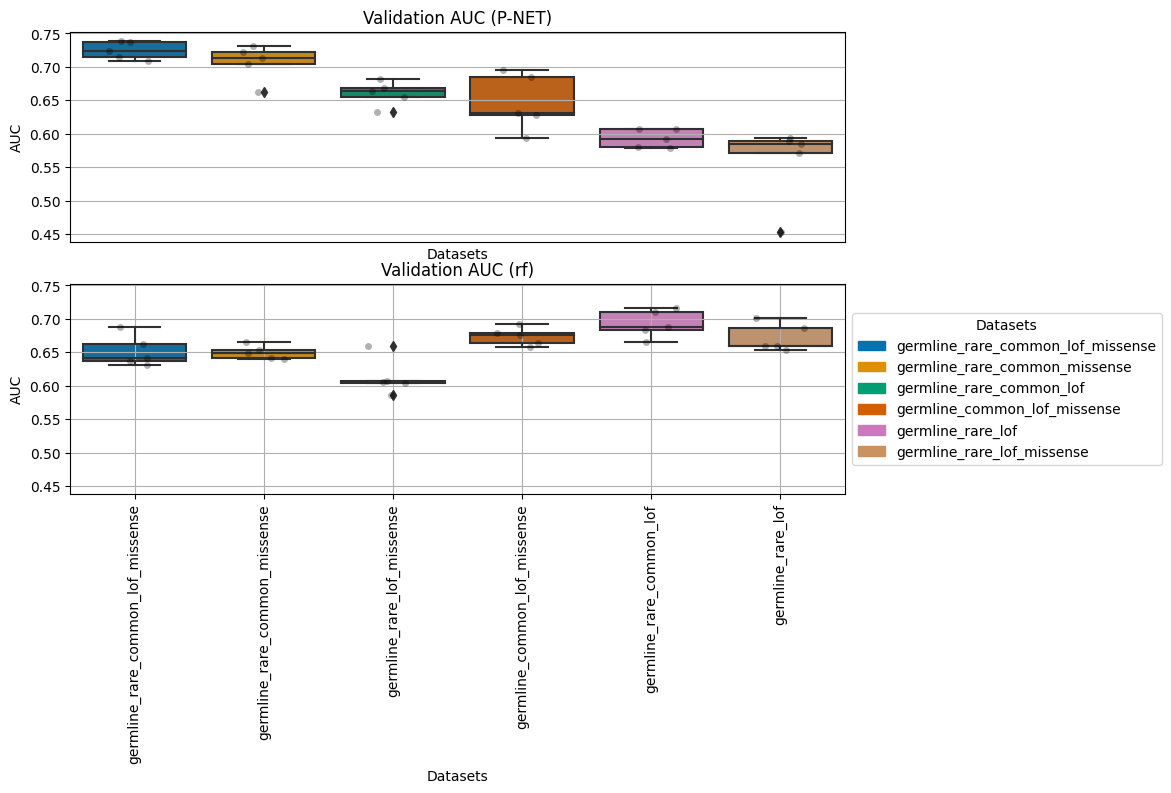

2025-04-29 21:38:07 INFO     [root] Somatic and germline data, plus somatic only
/var/tmp/ipykernel_154822/745935501.py:66: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.xticks([])  # Hide xticks


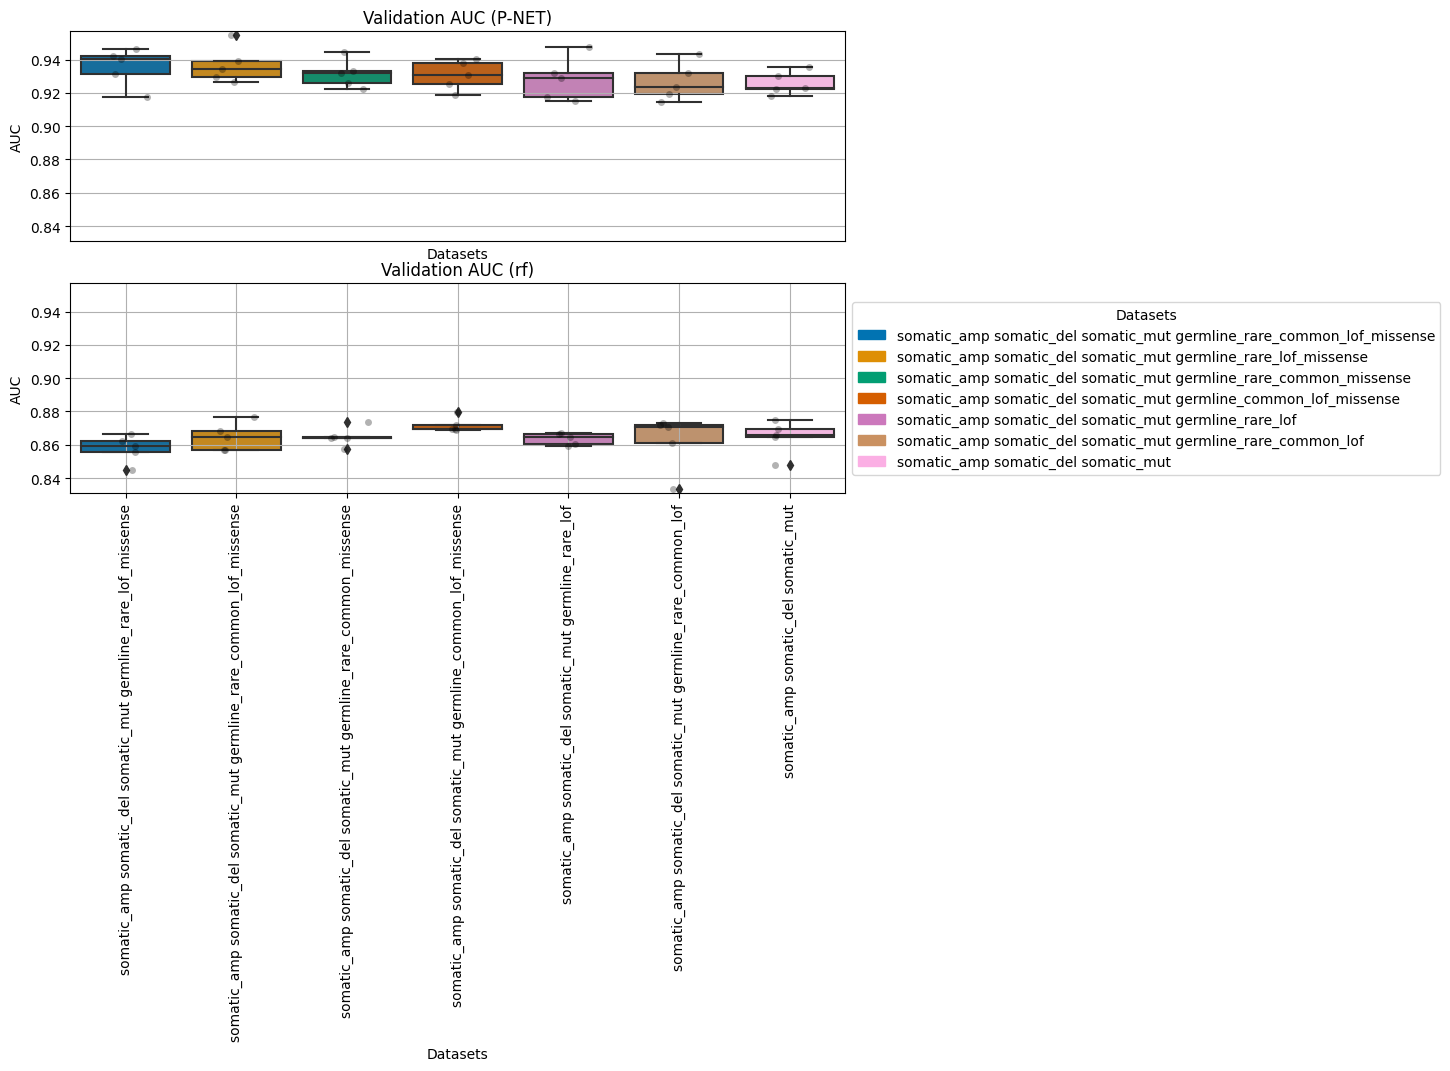

2025-04-29 21:38:08 INFO     [root] All data combos
/var/tmp/ipykernel_154822/745935501.py:66: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.xticks([])  # Hide xticks


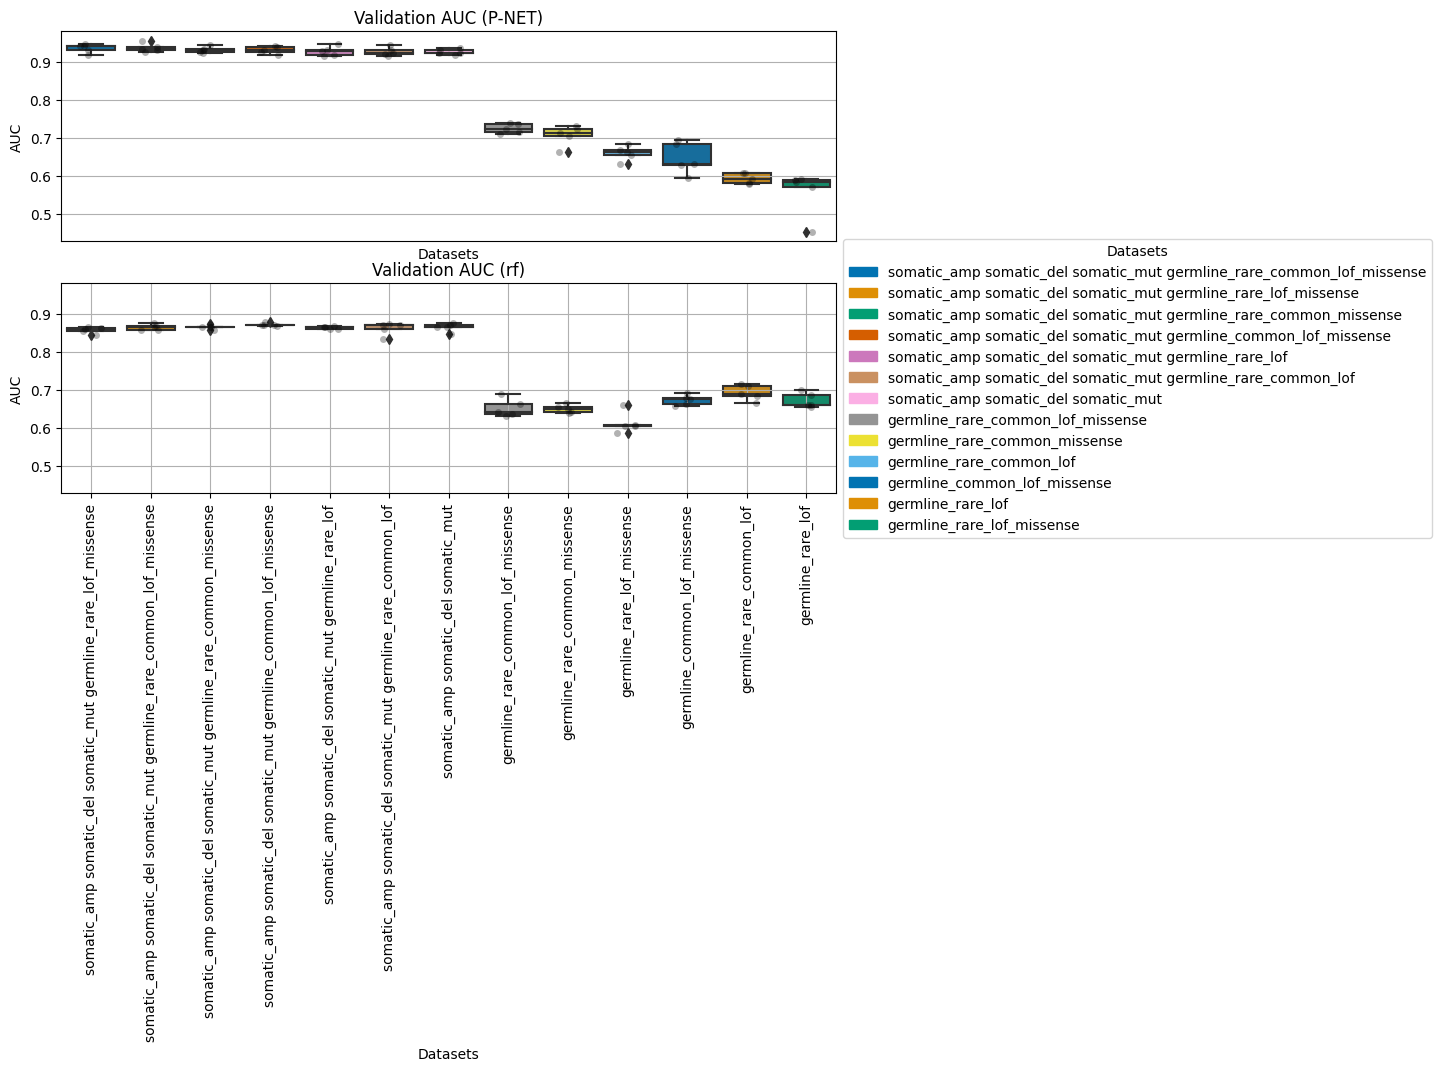

In [ ]:
def get_group_ordered_by_statistic(df, group_col_name, order_col_name='auc', stat="median", ascending=False):
    if stat=="mean":
        # Calculate mean for each dataset
        sorted_df = df.groupby(group_col_name)[order_col_name].mean().sort_values(ascending=ascending)
    elif stat=="median":
        # Calculate median for each dataset
        sorted_df = df.groupby(group_col_name)[order_col_name].median().sort_values(ascending=ascending)
    else:
        print("TODO: not implemented")
        return
    # Order the datasets by descending mean AUC
    group_order = sorted_df.index.tolist()
    return group_order


def plot_auc_boxplot_for_grouped_df(df, group_order=None):
    # TODO: wip. Start here.
    if group_order is None:
        # Extract unique dataset orders
        group_order = df['datasets'].unique()

    # Set color pallette and plot size
    pnet_palette = sns.color_palette('colorblind', n_colors=len(group_order))
    plt.figure(figsize=(10, 6))

    # Box plot for 'pnet' model type
    pnet_df = df[df['model_type'] == 'pnet']
    pnet_order = get_group_ordered_by_statistic(pnet_df, group_col_name="datasets")
    sns.boxplot(data=pnet_df, x='datasets', y='auc', order=pnet_order, dodge=True, palette=pnet_palette)
    sns.stripplot(data=pnet_df, x='datasets', y='auc', order=pnet_order, color='black', jitter=0.2, alpha=0.3)
    plt.title('Validation AUC (P-NET)')
    plt.xlabel('Datasets')
    plt.ylabel('AUC')
    plt.xticks([])  # Hide xticks
    plt.grid(True)

    # Set y-axis limits manually?
    plt.set_ylim(plt.get_ylim()[0], plt.get_ylim()[1])

    # Custom legend
    handles = [plt.Rectangle((0,0),1,1, color=color) for color in pnet_palette]
    plt.legend(handles, group_order, title='Datasets', loc='center left', bbox_to_anchor=(1, 0.5))

    return plt

def plot_boxplots(df, group_order=None):
    if group_order is None:
        # Extract unique dataset orders
        group_order = df['datasets'].unique()

    # Create color palette
    pnet_palette = sns.color_palette('colorblind', n_colors=len(group_order))

    # Create separate box-and-whisker plots for each model type
    plt.figure(figsize=(10, 6))

    # Box plot for 'pnet' model type
    ax1 = plt.subplot(2, 1, 1)
    pnet_df = df[df['model_type'] == 'pnet']
    pnet_order = get_group_ordered_by_statistic(pnet_df, group_col_name="datasets")
    sns.boxplot(data=pnet_df, x='datasets', y='auc', order=pnet_order, dodge=True, palette=pnet_palette)
    sns.stripplot(data=pnet_df, x='datasets', y='auc', order=pnet_order, color='black', jitter=0.2, alpha=0.3)
    plt.title('Validation AUC (P-NET)')
    plt.xlabel('Datasets')
    plt.ylabel('AUC')
    plt.xticks([])  # Hide xticks
    plt.grid(True)

    # Box plot for 'rf' model type
    ax2 = plt.subplot(2, 1, 2)
    rf_df = df[df['model_type'] == 'rf']
    sns.boxplot(data=rf_df, x='datasets', y='auc', order=pnet_order, dodge=True, palette=pnet_palette)
    sns.stripplot(data=rf_df, x='datasets', y='auc', order=pnet_order, color='black', jitter=0.2, alpha=0.3)
    plt.title('Validation AUC (rf)')
    plt.xlabel('Datasets')
    plt.ylabel('AUC')
    plt.xticks(rotation=90)
    plt.grid(True)

    # Set y-axis limits to be the same for both plots
    ymin = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
    ymax = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)

    # Custom legend
    handles = [plt.Rectangle((0,0),1,1, color=color) for color in pnet_palette]
    plt.legend(handles, group_order, title='Datasets', loc='center left', bbox_to_anchor=(1, 0.5))

    return plt

logging.info("Only germline data")
filtered_data = df[(~df['datasets'].str.contains('somatic'))] # Filtered dataset
plt = plot_boxplots(filtered_data)
plt.show()

logging.info("Somatic and germline data, plus somatic only")
filtered_data = df[(df['datasets'].str.contains('somatic') & df['datasets'].str.contains('germline')) | (df['datasets'] == "somatic_amp somatic_del somatic_mut")] # Filtered dataset
plt = plot_boxplots(filtered_data)
plt.show()

logging.info("All data combos")
filtered_data = df
plt = plot_boxplots(filtered_data)
plt.show()


/var/tmp/ipykernel_8534/183911096.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


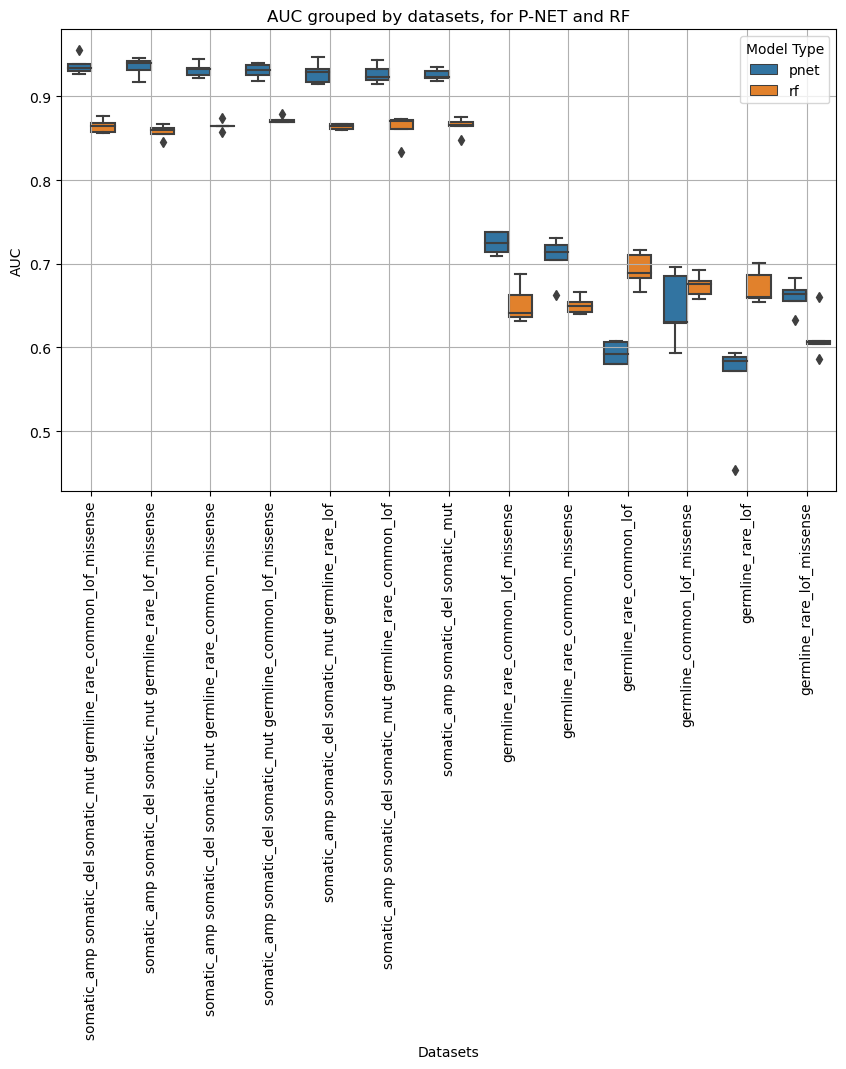

In [15]:
# Create a box-and-whisker plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='datasets', y='auc', hue='model_type', dodge=True)

# Add grid and legend
plt.grid(True)
plt.legend(title='Model Type')

# Set labels and title
plt.xlabel('Datasets')
plt.ylabel('AUC')
plt.title('AUC grouped by datasets, for P-NET and RF')
plt.xticks(rotation=90)

# Show plot
plt.tight_layout()
plt.show()

## P-NET feature importance (can also examine gene-level importance)
1. SNR (signal to noise ratio) as Marc G uses
2. Manual look at top-ranked genes (just using scores assigned by P-NET)

### SNR for P-NET

In [3]:
# Function to get top N features by SNR for each dataset
def get_top_n_features(df, n=10):
    top_features = {}
    for dataset in df.columns:
        top_features[dataset] = df[[dataset]].nlargest(n, dataset)
    return top_features


# Function to calculate the proportion of total mean importance score contributed by top N features for each dataset
def get_top_n_features_proportion(df, n=10):
    raise AssertionError("the function get_top_n_features_proportion() is not implemented correctly yet.")
    top_n_features_proportion = {}
    total_mean_importance = df.mean(axis=0)
    print(total_mean_importance)
    for dataset in df.columns:
        top_n_features_proportion[dataset] = df.nlargest(n, dataset)[dataset].sum() / total_mean_importance[dataset]
    return top_n_features_proportion

In [4]:
# Examining the impact of different input data
prostate_response = pd.read_csv('../../pnet_germline/data/pnet_database/prostate/processed/response_paper.csv')
prostate_response.rename(columns={'id': "Tumor_Sample_Barcode"}, inplace=True)
prostate_response.set_index('Tumor_Sample_Barcode', inplace=True)

import wandb
import pandas as pd

# Initialize the API
api = wandb.Api()

# Define parameters
who = "validation"
project_name = "prostate_met_status"
group_name = "pnet_somatic_and_germline_exp_003"
sweep_id = "cmlmrw2s" 

# Fetch the runs
runs = api.runs(project_name, filters={"sweep": sweep_id, "state": "finished"})

# Create an empty list to store DataFrames
dfs = []

for run in runs:
    model_type = run.config.get("model_type", "unknown")
    datasets = run.config.get("datasets", "unknown")
    subdir_name = f"{model_type}_eval_set_{who}"

    # Paths to feature and gene importances files
    feature_importances_path = f'../results/{group_name}/{subdir_name}/wandbID_{run.id}/{who}_gene_feature_importances.csv'
    gene_importances_path = f'../results/{group_name}/{subdir_name}/wandbID_{run.id}/{who}_gene_importances.csv'

    # Create a DataFrame for the current run
    df = pd.DataFrame({
        "run_id": [run.id],
        "model_type": [model_type],
        "datasets": [datasets],
        "feature_importances_path": [feature_importances_path],
        # "gene_importances_path": [gene_importances_path]
    })

    # Append the DataFrame to the list
    dfs.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
pnet_df = pd.concat(dfs, ignore_index=True)
pnet_df.set_index("run_id", inplace=True)

# Now you have a DataFrame containing the run information
# You can use this DataFrame to access the paths to feature and gene importances files
display(pnet_df)

,model_type,datasets,feature_importances_path
run_id,,,
z6txhc3m,rf,somatic_amp somatic_del somatic_mut germline_r...,../results/pnet_somatic_and_germline_exp_003/r...
6avv5zag,rf,somatic_amp somatic_del somatic_mut germline_r...,../results/pnet_somatic_and_germline_exp_003/r...
t432uwo7,rf,somatic_amp somatic_del somatic_mut germline_r...,../results/pnet_somatic_and_germline_exp_003/r...
2gffdeya,rf,somatic_amp somatic_del somatic_mut germline_r...,../results/pnet_somatic_and_germline_exp_003/r...
5x0xm2se,rf,somatic_amp somatic_del somatic_mut germline_r...,../results/pnet_somatic_and_germline_exp_003/r...
...,...,...,...
ah1z52n1,pnet,somatic_amp somatic_del somatic_mut,../results/pnet_somatic_and_germline_exp_003/p...
jxwgy3eb,pnet,somatic_amp somatic_del somatic_mut,../results/pnet_somatic_and_germline_exp_003/p...
pz7vf9xo,pnet,somatic_amp somatic_del somatic_mut,../results/pnet_somatic_and_germline_exp_003/p...


In [16]:
# Examining the h1 regularization experiment results
prostate_response = pd.read_csv('../../pnet_germline/data/pnet_database/prostate/processed/response_paper.csv')
prostate_response.rename(columns={'id': "Tumor_Sample_Barcode"}, inplace=True)
prostate_response.set_index('Tumor_Sample_Barcode', inplace=True)

import wandb
import pandas as pd

# Initialize the API
api = wandb.Api()

# Define parameters
who = "validation"
project_name = "prostate_met_status"
group_name = "pnet_h1_regularization_001"
sweep_id = "g8cl6qur" 

# Fetch the runs
runs = api.runs(project_name, filters={"sweep": sweep_id, "state": "finished"})

# Create an empty list to store DataFrames
dfs = []

for run in runs:
    model_type = run.config.get("model_type", "unknown")
    h1_alpha = run.config.get("h1_alpha", "unknown")
    datasets = run.config.get("datasets", "unknown")
    h1_regularization_method = run.config.get("h1_regularization_method", "unknown")
    subdir_name = f"{model_type}_eval_set_{who}"

    # Paths to feature and gene importances files
    feature_importances_path = f'../results/{group_name}/{subdir_name}/wandbID_{run.id}/{who}_gene_feature_importances.csv'
    gene_importances_path = f'../results/{group_name}/{subdir_name}/wandbID_{run.id}/{who}_gene_importances.csv'

    # Create a DataFrame for the current run
    df = pd.DataFrame({
        "run_id": [run.id],
        "model_type": [model_type],
        "datasets": [datasets],
        "h1_alpha": [h1_alpha],
        "h1_regularization_method": [h1_regularization_method],
        "feature_importances_path": [feature_importances_path],
        # "gene_importances_path": [gene_importances_path]
    })

    # Append the DataFrame to the list
    dfs.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
h1_df = pd.concat(dfs, ignore_index=True)
h1_df.set_index("run_id", inplace=True)

# Now you have a DataFrame containing the run information
# You can use this DataFrame to access the paths to feature and gene importances files
display(h1_df)

,model_type,datasets,h1_alpha,h1_regularization_method,feature_importances_path
run_id,,,,,
74hzml9p,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
uto837ib,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
jicryzqr,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
w9nsi3ri,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
mfjtgj1q,pnet,somatic_amp somatic_del somatic_mut,1.0,l2,../results/pnet_h1_regularization_001/pnet_eva...
...,...,...,...,...,...
7qgy2d9u,pnet,somatic_amp somatic_del somatic_mut,0.0,l2,../results/pnet_h1_regularization_001/pnet_eva...
kyh36sk6,pnet,somatic_amp somatic_del somatic_mut,0.0,l1,../results/pnet_h1_regularization_001/pnet_eva...
562lu4c0,pnet,somatic_amp somatic_del somatic_mut,0.0,l1,../results/pnet_h1_regularization_001/pnet_eva...


In the below code:
1. We use dictionaries imps_by_dataset and ranks_by_dataset to store feature importances and ranks grouped by dataset.
1. For each row in pnet_df, we append the importances and ranks to the appropriate dataset list.
1. After collecting the data, we convert each dataset's list into a DataFrame.
1. We compute the SNR for each dataset and store the results in a dictionary.
1. Finally, we convert the SNR dictionary to a DataFrame for easier handling and analysis

In [17]:
wandb_sweep_df = h1_df #pnet_df
wandb_sweep_df

,model_type,datasets,h1_alpha,h1_regularization_method,feature_importances_path
run_id,,,,,
74hzml9p,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
uto837ib,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
jicryzqr,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
w9nsi3ri,pnet,somatic_amp somatic_del somatic_mut,1.0,elasticnet,../results/pnet_h1_regularization_001/pnet_eva...
mfjtgj1q,pnet,somatic_amp somatic_del somatic_mut,1.0,l2,../results/pnet_h1_regularization_001/pnet_eva...
...,...,...,...,...,...
7qgy2d9u,pnet,somatic_amp somatic_del somatic_mut,0.0,l2,../results/pnet_h1_regularization_001/pnet_eva...
kyh36sk6,pnet,somatic_amp somatic_del somatic_mut,0.0,l1,../results/pnet_h1_regularization_001/pnet_eva...
562lu4c0,pnet,somatic_amp somatic_del somatic_mut,0.0,l1,../results/pnet_h1_regularization_001/pnet_eva...


In [18]:
import pandas as pd

# Initialize dictionaries to store data by key
imps_by_key = {}
ranks_by_key = {}


# Ensure the DataFrame has a 'dataset' column or a column to group by
if 'h1_alpha' not in wandb_sweep_df.columns:
    raise ValueError("The DataFrame must contain a 'h1_alpha' column to group by")

# Loop through the rows of the DataFrame containing run information
for index, row in wandb_sweep_df.iterrows():
    importances_path = row['feature_importances_path']
    imps = pd.read_csv(importances_path).set_index('Unnamed: 0')
    
    # Read feature importances from the specified file path
    imps = imps.join(prostate_response).groupby('response').mean().diff(axis=0).iloc[1]
    
    ranks = imps.rank(ascending=False)
    
    key = row['h1_regularization_method']+'_'+row['h1_alpha']
    
    # Initialize lists for the key if not already present
    if key not in imps_by_key:
        imps_by_key[key] = []
        ranks_by_key[key] = []
    
    # Store the results in the corresponding key lists
    imps_by_key[key].append(imps)
    ranks_by_key[key].append(ranks)

# Create DataFrames for feature importances and ranks by key
df_imps_by_key = {key: pd.DataFrame(imps_list) for key, imps_list in imps_by_key.items()}
df_ranks_by_key = {key: pd.DataFrame(ranks_list) for key, ranks_list in ranks_by_key.items()}

# Calculate signal-to-noise ratio (SNR) for each key
snr_per_key = {}
for key, df_imps in df_imps_by_key.items():
    snr = df_imps.mean(axis=0) / (df_imps.std(axis=0) + 1e-9)
    snr_per_key[key] = snr

# Convert the SNR dictionary to a DataFrame for easier handling
snr_df = pd.DataFrame(snr_per_key).transpose().reset_index().rename(columns={'index': 'key'})

display(snr_df)

TypeError: can only concatenate str (not "float") to str

In [7]:
# Initialize an empty DataFrame to store the top 10 values by P-NET rank for each dataset
top_10_df = pd.DataFrame()

# Iterate over df_ranks_by_dataset dictionary
for dataset, df in df_imps_by_dataset.items():
    # Calculate the mean ranking for each run and select the top 10
    top_10 = df.mean(axis=0).sort_values(ascending=False)[:10]
    
    # Add the top 10 values as a column to the DataFrame
    top_10_df[dataset] = top_10.index

# Set the index of the DataFrame to be 1 through 10
top_10_df.index = range(1, 11)

# Display the DataFrame
print("Top features by P-NET importance score:")
display(top_10_df)


Top features by P-NET importance score:


,somatic_amp somatic_del somatic_mut germline_rare_common_missense,somatic_amp somatic_del somatic_mut germline_rare_common_lof,somatic_amp somatic_del somatic_mut germline_common_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense,germline_rare_common_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_lof,germline_common_lof_missense,germline_rare_lof_missense,germline_rare_common_missense,germline_rare_common_lof,germline_rare_lof,somatic_amp somatic_del somatic_mut
1,AR_somatic_amp,AR_somatic_amp,AR_somatic_amp,AR_somatic_amp,AR_somatic_amp,AR_germline_rare_common_lof_missense,AR_somatic_amp,ATM_germline_common_lof_missense,HLA-A_germline_rare_lof_missense,AR_germline_rare_common_missense,BRCA2_germline_rare_common_lof,BRCA2_germline_rare_lof,AR_somatic_amp
2,AR_somatic_mut,AR_somatic_mut,AR_somatic_mut,AR_somatic_mut,AR_somatic_mut,ATM_germline_rare_common_lof_missense,AR_somatic_mut,AR_germline_common_lof_missense,AR_germline_rare_lof_missense,GNAS_germline_rare_common_missense,HLA-A_germline_rare_common_lof,HLA-A_germline_rare_lof,AR_somatic_mut
3,TP53_somatic_mut,TP53_somatic_mut,TP53_somatic_mut,TP53_somatic_mut,TP53_somatic_mut,GNAS_germline_rare_common_lof_missense,TP53_somatic_mut,STRN_germline_common_lof_missense,GNAS_germline_rare_lof_missense,ATM_germline_rare_common_missense,SBDS_germline_rare_common_lof,WNK2_germline_rare_lof,TP53_somatic_mut
4,AR_germline_rare_common_missense,PTEN_somatic_del,PTEN_somatic_del,PTEN_somatic_del,PTEN_somatic_del,MUC4_germline_rare_common_lof_missense,PTEN_somatic_del,NFKBIE_germline_common_lof_missense,RBM15_germline_rare_lof_missense,HLA-A_germline_rare_common_missense,WNK2_germline_rare_common_lof,SBDS_germline_rare_lof,PTEN_somatic_del
5,PTEN_somatic_del,MAML3_somatic_del,AR_germline_common_lof_missense,AR_germline_rare_lof_missense,AR_germline_rare_common_lof_missense,HLA-A_germline_rare_common_lof_missense,MUC4_somatic_mut,WNK2_germline_common_lof_missense,DCTN1_germline_rare_lof_missense,RBM15_germline_rare_common_missense,PMS2_germline_rare_common_lof,PMS2_germline_rare_lof,PDGFA_somatic_amp
6,ATM_germline_rare_common_missense,BRCA2_somatic_del,RBBP5_somatic_amp,GNAS_somatic_mut,GNAS_somatic_mut,RAD17_germline_rare_common_lof_missense,BRCA2_somatic_del,NCOA1_germline_common_lof_missense,RAD17_germline_rare_lof_missense,MUC4_germline_rare_common_missense,PMS1_germline_rare_common_lof,PMS1_germline_rare_lof,MUC4_somatic_mut
7,GNAS_somatic_mut,RBBP5_somatic_amp,APC_somatic_mut,MAML3_somatic_del,ATM_germline_rare_common_lof_missense,RBM15_germline_rare_common_lof_missense,RAC1_somatic_amp,HLA-A_germline_common_lof_missense,MAPK1_germline_rare_lof_missense,MAPK1_germline_rare_common_missense,AKAP9_germline_rare_common_lof,AKAP9_germline_rare_lof,MAML3_somatic_del
8,GNAS_germline_rare_common_missense,MUC4_somatic_mut,GNAS_somatic_mut,COL1A2_somatic_amp,RAC1_somatic_amp,APC_germline_rare_common_lof_missense,GNAS_somatic_mut,PRDM2_germline_common_lof_missense,MUC4_germline_rare_lof_missense,WWTR1_germline_rare_common_missense,ROBO2_germline_rare_common_lof,AGL_germline_rare_lof,RB1_somatic_del
9,RBBP5_somatic_amp,GNAS_somatic_mut,COL1A2_somatic_amp,APC_somatic_mut,GNAS_germline_rare_common_lof_missense,DCTN1_germline_rare_common_lof_missense,HLA-A_germline_rare_lof,GNAS_germline_common_lof_missense,TPR_germline_rare_lof_missense,DCTN1_germline_rare_common_missense,AGL_germline_rare_common_lof,UROD_germline_rare_lof,GNAS_somatic_mut
10,APC_somatic_mut,RAC1_somatic_amp,PDGFA_somatic_amp,RAC1_somatic_amp,APC_somatic_mut,STRN_germline_rare_common_lof_missense,OBSCN_somatic_del,LRP1B_germline_common_lof_missense,FAT4_germline_rare_lof_missense,RAD17_germline_rare_common_missense,MPL_germline_rare_common_lof,ECT2L_germline_rare_lof,APC_somatic_mut


In [9]:
print("INTS3_somatic_del: High SNR score even though not important due to low variability run-to-run")
print(df_imps_by_dataset['somatic_amp somatic_del somatic_mut']['INTS3_somatic_del'])
print('')
print("AR_somatic_amp: Less high SNR score even though very important due to higher variability")
print(df_imps_by_dataset['somatic_amp somatic_del somatic_mut']['AR_somatic_amp'])

INTS3_somatic_del: High SNR score even though not important due to low variability run-to-run
1    0.001792
1    0.001876
1    0.001922
1    0.001658
1    0.001535
Name: INTS3_somatic_del, dtype: float64

AR_somatic_amp: Less high SNR score even though very important due to higher variability
1    1.518947
1    0.943128
1    1.122794
1    0.882286
1    0.903952
Name: AR_somatic_amp, dtype: float64


In [9]:
# Initialize an empty DataFrame to store the top 10 values by P-NET rank for each dataset
top_10_df = pd.DataFrame()

# Iterate over df_ranks_by_dataset dictionary
for dataset, rankdf in df_ranks_by_dataset.items():
    # Calculate the mean ranking for each run and select the top 10
    top_10 = rankdf.mean(axis=0).sort_values(ascending=True)[:10]
    
    # Add the top 10 values as a column to the DataFrame
    top_10_df[dataset] = top_10.index

# Set the index of the DataFrame to be 1 through 10
top_10_df.index = range(1, 11)

# Display the DataFrame
print("Top features by P-NET ranking:")
display(top_10_df)


Top features by P-NET ranking:


,somatic_amp somatic_del somatic_mut germline_rare_common_missense,somatic_amp somatic_del somatic_mut germline_rare_common_lof,somatic_amp somatic_del somatic_mut germline_common_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense,germline_rare_common_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_lof,germline_common_lof_missense,germline_rare_lof_missense,germline_rare_common_missense,germline_rare_common_lof,germline_rare_lof,somatic_amp somatic_del somatic_mut
1,AR_somatic_amp,AR_somatic_amp,AR_somatic_amp,AR_somatic_amp,AR_somatic_amp,AR_germline_rare_common_lof_missense,AR_somatic_amp,ATM_germline_common_lof_missense,HLA-A_germline_rare_lof_missense,AR_germline_rare_common_missense,BRCA2_germline_rare_common_lof,BRCA2_germline_rare_lof,AR_somatic_amp
2,TP53_somatic_mut,AR_somatic_mut,AR_somatic_mut,AR_somatic_mut,AR_somatic_mut,ATM_germline_rare_common_lof_missense,AR_somatic_mut,AR_germline_common_lof_missense,GNAS_germline_rare_lof_missense,GNAS_germline_rare_common_missense,HLA-A_germline_rare_common_lof,HLA-A_germline_rare_lof,AR_somatic_mut
3,AR_somatic_mut,TP53_somatic_mut,TP53_somatic_mut,TP53_somatic_mut,TP53_somatic_mut,MUC4_germline_rare_common_lof_missense,TP53_somatic_mut,STRN_germline_common_lof_missense,AR_germline_rare_lof_missense,ATM_germline_rare_common_missense,SBDS_germline_rare_common_lof,PMS2_germline_rare_lof,TP53_somatic_mut
4,PTEN_somatic_del,PTEN_somatic_del,PTEN_somatic_del,PTEN_somatic_del,AR_germline_rare_common_lof_missense,HLA-A_germline_rare_common_lof_missense,PTEN_somatic_del,GNAS_germline_common_lof_missense,DCTN1_germline_rare_lof_missense,HLA-A_germline_rare_common_missense,PMS1_germline_rare_common_lof,WNK2_germline_rare_lof,PTEN_somatic_del
5,ATM_germline_rare_common_missense,MAML3_somatic_del,AR_germline_common_lof_missense,AR_germline_rare_lof_missense,PTEN_somatic_del,RAD17_germline_rare_common_lof_missense,BRCA2_somatic_del,NFKBIE_germline_common_lof_missense,RAD17_germline_rare_lof_missense,RBM15_germline_rare_common_missense,AKAP9_germline_rare_common_lof,AKAP9_germline_rare_lof,RB1_somatic_del
6,AR_germline_rare_common_missense,BRCA2_somatic_del,GNAS_somatic_mut,GNAS_somatic_mut,ATM_germline_rare_common_lof_missense,APC_germline_rare_common_lof_missense,MUC4_somatic_mut,PRDM2_germline_common_lof_missense,MAPK1_germline_rare_lof_missense,DCTN1_germline_rare_common_missense,PMS2_germline_rare_common_lof,AGL_germline_rare_lof,MUC4_somatic_mut
7,GNAS_somatic_mut,RAC1_somatic_amp,COL1A2_somatic_amp,APC_somatic_mut,GNAS_somatic_mut,RBM15_germline_rare_common_lof_missense,RAC1_somatic_amp,NRG1_germline_common_lof_missense,TPR_germline_rare_lof_missense,STRN_germline_rare_common_missense,WNK2_germline_rare_common_lof,SBDS_germline_rare_lof,MAML3_somatic_del
8,GNAS_germline_rare_common_missense,MUC4_somatic_mut,RBBP5_somatic_amp,RAC1_somatic_amp,GNAS_germline_rare_common_lof_missense,DCTN1_germline_rare_common_lof_missense,PDGFA_somatic_amp,LRP1B_germline_common_lof_missense,MUC4_germline_rare_lof_missense,MAPK1_germline_rare_common_missense,MPL_germline_rare_common_lof,PMS1_germline_rare_lof,PDGFA_somatic_amp
9,RBBP5_somatic_amp,OBSCN_somatic_del,PDGFA_somatic_amp,MAML3_somatic_del,APC_somatic_mut,SBDS_germline_rare_common_lof_missense,GNAS_somatic_mut,CNBD1_germline_common_lof_missense,TRRAP_germline_rare_lof_missense,ERBB2_germline_rare_common_missense,ECT2L_germline_rare_common_lof,UROD_germline_rare_lof,GNAS_somatic_mut
10,MAML3_somatic_del,MAP3K7_somatic_del,MAML3_somatic_del,COL1A2_somatic_amp,MAML3_somatic_del,AXIN1_germline_rare_common_lof_missense,MDM4_somatic_amp,N4BP2_germline_common_lof_missense,RBM15_germline_rare_lof_missense,WWTR1_germline_rare_common_missense,PDCD1LG2_germline_rare_common_lof,ECT2L_germline_rare_lof,RBBP5_somatic_amp


In [16]:
# # Get top 10 features by P-NET ranking for each dataset
# top_n_features_pnet_rank = get_top_n_features(df_ranks_by_dataset, n=10)

# # Display the results
# for dataset, top_features in top_n_features_pnet_rank.items():
#     print(f"Top {len(top_features)} P-NET ranked features for {dataset}:")
#     display(top_features)
#     print()


In [34]:
top_n_features['somatic_amp somatic_del somatic_mut']

,somatic_amp somatic_del somatic_mut
INTS3_somatic_del,11.027664
HEG1_somatic_amp,6.874283
GPATCH4_somatic_amp,5.792479
POLR2B_somatic_del,5.644715
AR_somatic_mut,5.536145
TP53_somatic_mut,5.379270
MAPK8_somatic_amp,5.369154
COL1A2_somatic_amp,4.802058
MTOR_somatic_mut,4.689627
RB1_somatic_mut,4.615682


In [13]:
# Get top 10 features by SNR for each dataset
top_n_features = get_top_n_features(pd.DataFrame(snr_per_dataset), n=10)

# Display the results
for dataset, top_features in top_n_features.items():
    print(f"Top {len(top_features)} features for {dataset}:")
    display(top_features)
    print()

Top 10 features for somatic_amp somatic_del somatic_mut germline_rare_common_missense:


,somatic_amp somatic_del somatic_mut germline_rare_common_missense
AR_somatic_amp,12.657766
WWTR1_somatic_amp,9.614320
NET1_somatic_amp,7.235092
OR5D14_somatic_del,6.551472
OR5AC2_somatic_del,6.029739
ZNF25_somatic_amp,5.722802
ATM_germline_rare_common_missense,5.566308
AR_somatic_mut,5.142633
MDC1_somatic_amp,4.873483
MAML3_somatic_del,4.746465



Top 10 features for somatic_amp somatic_del somatic_mut germline_rare_common_lof:


,somatic_amp somatic_del somatic_mut germline_rare_common_lof
OBSCN_somatic_mut,13.001014
AR_somatic_mut,9.373237
COL1A2_somatic_amp,7.756998
AR_somatic_amp,7.576128
COL3A1_somatic_del,6.244593
COL3A1_somatic_amp,5.999336
TGOLN2_somatic_amp,5.926508
AHR_somatic_del,5.681797
AP2A2_somatic_del,5.541884
BIRC2_somatic_del,5.471237



Top 10 features for somatic_amp somatic_del somatic_mut germline_common_lof_missense:


...

,germline_rare_common_lof
PMS1_germline_rare_common_lof,2.168969
AKAP9_germline_rare_common_lof,1.709645
BRCA2_germline_rare_common_lof,1.602745
PMS2_germline_rare_common_lof,1.485884
MPL_germline_rare_common_lof,1.389842
SBDS_germline_rare_common_lof,1.202711
HLA-A_germline_rare_common_lof,1.188967
WNK2_germline_rare_common_lof,0.969504
ROBO2_germline_rare_common_lof,0.464506
ECT2L_germline_rare_common_lof,0.438385



Top 10 features for germline_rare_lof:


,germline_rare_lof
BRCA2_germline_rare_lof,3.880243
PMS2_germline_rare_lof,1.648884
HLA-A_germline_rare_lof,1.222405
AKAP9_germline_rare_lof,0.913564
WNK2_germline_rare_lof,0.838436
SBDS_germline_rare_lof,0.821868
AGL_germline_rare_lof,0.628927
MPL_germline_rare_lof,0.622598
PMS1_germline_rare_lof,0.565146
XPA_germline_rare_lof,0.277084



Top 10 features for somatic_amp somatic_del somatic_mut:


,somatic_amp somatic_del somatic_mut
INTS3_somatic_del,11.027664
HEG1_somatic_amp,6.874283
GPATCH4_somatic_amp,5.792479
POLR2B_somatic_del,5.644715
AR_somatic_mut,5.536145
TP53_somatic_mut,5.379270
MAPK8_somatic_amp,5.369154
COL1A2_somatic_amp,4.802058
MTOR_somatic_mut,4.689627
RB1_somatic_mut,4.615682


In [45]:
# Here we calculate SNR for each group ("datasets") separately to see how the top-ranked genes change with different inputs

# Initialize empty dictionaries to store results for each dataset group
snr_dict = {}

# Restrict to just P-NET models for now
pnet_df = pnet_df[pnet_df['model_type'] == "pnet"]

# Loop through each dataset group
for dataset_group in pnet_df['datasets'].unique():
    # Filter the DataFrame to include only rows corresponding to the current dataset group
    dataset_group_df = pnet_df[pnet_df['datasets'] == dataset_group]
    
    # Initialize empty DataFrames to store results for the current dataset group
    df_imps = pd.DataFrame()
    df_ranks = pd.DataFrame()
    
    # Loop through the rows of the DataFrame containing run information for the current dataset group
    for index, row in dataset_group_df.iterrows():
        importances_path = row['feature_importances_path']
        imps = pd.read_csv(importances_path).set_index('Unnamed: 0')

        # Read feature importances from the specified file path
        imps = imps.join(prostate_response).groupby('response').mean().diff(axis=0).iloc[1]

        ranks = imps.rank(ascending=False)

        # Store results in separate DataFrames for the current dataset group
        df_imps[f'{index}'] = imps
        df_ranks[f'{index}'] = ranks

    # Calculate signal-to-noise ratio (SNR) for the current dataset group
    snr = df_imps.mean(axis=1) / (df_imps.std(axis=1) + 1e-9)
    
    # Store the SNR results for the current dataset group in the dictionary
    snr_dict[dataset_group] = snr.sort_values(ascending=False)

# Now, snr_dict contains SNR results for each dataset group
snr_dict

{'somatic_amp somatic_del somatic_mut germline_rare_common_missense': AR_somatic_amp                         12.657766
 WWTR1_somatic_amp                       9.614320
 NET1_somatic_amp                        7.235092
 OR5D14_somatic_del                      6.551472
 OR5AC2_somatic_del                      6.029739
                                          ...    
 TCEA1_germline_rare_common_missense    -4.596067
 KDM3B_somatic_mut                      -4.990922
 ZNF195_somatic_mut                     -5.342789
 HSP90AB1_somatic_amp                   -6.990605
 OR5D14_somatic_mut                     -7.661929
 Length: 19416, dtype: float64,
 'somatic_amp somatic_del somatic_mut germline_rare_common_lof': OBSCN_somatic_mut     13.001014
 AR_somatic_mut         9.373237
 COL1A2_somatic_amp     7.756998
 AR_somatic_amp         7.576128
 COL3A1_somatic_del     6.244593
                         ...    
 SEC24C_somatic_del    -3.892194
 CSF3R_somatic_del     -4.399042
 VCL_somatic_del     

In [83]:
# Initialize an empty DataFrame to store the top 10 values by P-NET rank for each dataset
top_10_snr_df = pd.DataFrame()

# Iterate over df_ranks_by_dataset dictionary
for dataset, df in snr_dict.items():
    # Calculate the mean ranking for each run and select the top 10
    top_10 = df.sort_values(ascending=False)[:10]
    
    # Add the top 10 values as a column to the DataFrame
    top_10_snr_df[dataset] = top_10.index

# Set the index of the DataFrame to be 1 through 10
top_10_snr_df.index = range(1, 11)

# Display the DataFrame
print("Top features by SNR score:")
display(top_10_snr_df)


Top features by SNR score:


,somatic_amp somatic_del somatic_mut germline_rare_common_missense,somatic_amp somatic_del somatic_mut germline_rare_common_lof,somatic_amp somatic_del somatic_mut germline_common_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_common_lof_missense,germline_rare_common_lof_missense,somatic_amp somatic_del somatic_mut germline_rare_lof,germline_common_lof_missense,germline_rare_lof_missense,germline_rare_common_missense,germline_rare_common_lof,germline_rare_lof,somatic_amp somatic_del somatic_mut
1,AR_somatic_amp,OBSCN_somatic_mut,TP53_somatic_mut,AR_somatic_mut,SNAPC3_somatic_amp,ATM_germline_rare_common_lof_missense,SSU72_somatic_del,MUC4_germline_common_lof_missense,PTPRC_germline_rare_lof_missense,PTPRC_germline_rare_common_missense,PMS1_germline_rare_common_lof,BRCA2_germline_rare_lof,INTS3_somatic_del
2,WWTR1_somatic_amp,AR_somatic_mut,COL3A1_somatic_amp,AR_somatic_amp,AR_somatic_amp,DDB2_germline_rare_common_lof_missense,MAPK8_somatic_amp,ATM_germline_common_lof_missense,AGL_germline_rare_lof_missense,DCTN1_germline_rare_common_missense,AKAP9_germline_rare_common_lof,PMS2_germline_rare_lof,HEG1_somatic_amp
3,NET1_somatic_amp,COL1A2_somatic_amp,AR_somatic_amp,TP53_somatic_mut,AR_somatic_mut,AR_germline_rare_common_lof_missense,TP53_somatic_mut,PREX2_germline_common_lof_missense,DCTN1_germline_rare_lof_missense,TPR_germline_rare_common_missense,BRCA2_germline_rare_common_lof,HLA-A_germline_rare_lof,GPATCH4_somatic_amp
4,OR5D14_somatic_del,AR_somatic_amp,GNAS_germline_common_lof_missense,RAD17_germline_rare_lof_missense,KRAS_somatic_amp,HLA-A_germline_rare_common_lof_missense,HIST1H3E_somatic_amp,AR_germline_common_lof_missense,ERCC2_germline_rare_lof_missense,ATM_germline_rare_common_missense,PMS2_germline_rare_common_lof,AKAP9_germline_rare_lof,POLR2B_somatic_del
5,OR5AC2_somatic_del,COL3A1_somatic_del,DCST1_somatic_amp,GNAS_somatic_mut,PRKDC_somatic_mut,MUC4_germline_rare_common_lof_missense,COL1A2_somatic_amp,GNAS_germline_common_lof_missense,MAML2_germline_rare_lof_missense,GNAS_germline_rare_common_missense,MPL_germline_rare_common_lof,WNK2_germline_rare_lof,AR_somatic_mut
6,ZNF25_somatic_amp,COL3A1_somatic_amp,ATM_germline_common_lof_missense,PTEN_somatic_del,MAML3_somatic_amp,CHEK2_germline_rare_common_lof_missense,IL11RA_somatic_del,CTNND1_germline_common_lof_missense,GNAS_germline_rare_lof_missense,AR_germline_rare_common_missense,SBDS_germline_rare_common_lof,SBDS_germline_rare_lof,TP53_somatic_mut
7,ATM_germline_rare_common_missense,TGOLN2_somatic_amp,PTEN_somatic_del,GNAS_germline_rare_lof_missense,STIP1_somatic_del,RAD17_germline_rare_common_lof_missense,CASP9_somatic_del,FLT3_germline_common_lof_missense,TNC_germline_rare_lof_missense,NBN_germline_rare_common_missense,HLA-A_germline_rare_common_lof,AGL_germline_rare_lof,MAPK8_somatic_amp
8,AR_somatic_mut,AHR_somatic_del,AR_somatic_mut,DPP4_somatic_del,AR_germline_rare_common_lof_missense,NCOA4_germline_rare_common_lof_missense,ARNT_somatic_amp,PDE4DIP_germline_common_lof_missense,HLA-A_germline_rare_lof_missense,A1CF_germline_rare_common_missense,WNK2_germline_rare_common_lof,MPL_germline_rare_lof,COL1A2_somatic_amp
9,MDC1_somatic_amp,AP2A2_somatic_del,PRPF3_somatic_amp,RAC1_somatic_amp,LAMC1_somatic_amp,MDM4_germline_rare_common_lof_missense,FABP7_somatic_del,LRP1B_germline_common_lof_missense,ATM_germline_rare_lof_missense,STRN_germline_rare_common_missense,ROBO2_germline_rare_common_lof,PMS1_germline_rare_lof,MTOR_somatic_mut
10,MAML3_somatic_del,BIRC2_somatic_del,STIP1_somatic_del,DCTN1_germline_rare_lof_missense,GTF2H4_somatic_amp,S100A7_germline_rare_common_lof_missense,UBE2F_somatic_del,FAT1_germline_common_lof_missense,TPR_germline_rare_lof_missense,ERBB2_germline_rare_common_missense,ECT2L_germline_rare_common_lof,XPA_germline_rare_lof,RB1_somatic_mut


In [47]:
for k, s in snr_dict.items():
    print(f"{k}")
    display(s[:10])

/nsomatic_amp somatic_del somatic_mut germline_rare_common_missense


AR_somatic_amp                       12.657766
WWTR1_somatic_amp                     9.614320
NET1_somatic_amp                      7.235092
OR5D14_somatic_del                    6.551472
OR5AC2_somatic_del                    6.029739
ZNF25_somatic_amp                     5.722802
ATM_germline_rare_common_missense     5.566308
AR_somatic_mut                        5.142633
MDC1_somatic_amp                      4.873483
MAML3_somatic_del                     4.746465
dtype: float64

/nsomatic_amp somatic_del somatic_mut germline_rare_common_lof


OBSCN_somatic_mut     13.001014
AR_somatic_mut         9.373237
COL1A2_somatic_amp     7.756998
AR_somatic_amp         7.576128
COL3A1_somatic_del     6.244593
COL3A1_somatic_amp     5.999336
TGOLN2_somatic_amp     5.926508
AHR_somatic_del        5.681797
AP2A2_somatic_del      5.541884
BIRC2_somatic_del      5.471237
dtype: float64

/nsomatic_amp somatic_del somatic_mut germline_common_lof_missense


...

PMS1_germline_rare_common_lof     2.168969
AKAP9_germline_rare_common_lof    1.709645
BRCA2_germline_rare_common_lof    1.602745
PMS2_germline_rare_common_lof     1.485884
MPL_germline_rare_common_lof      1.389842
SBDS_germline_rare_common_lof     1.202711
HLA-A_germline_rare_common_lof    1.188967
WNK2_germline_rare_common_lof     0.969504
ROBO2_germline_rare_common_lof    0.464506
ECT2L_germline_rare_common_lof    0.438385
dtype: float64

/ngermline_rare_lof


BRCA2_germline_rare_lof    3.880243
PMS2_germline_rare_lof     1.648884
HLA-A_germline_rare_lof    1.222405
AKAP9_germline_rare_lof    0.913564
WNK2_germline_rare_lof     0.838436
SBDS_germline_rare_lof     0.821868
AGL_germline_rare_lof      0.628927
MPL_germline_rare_lof      0.622598
PMS1_germline_rare_lof     0.565146
XPA_germline_rare_lof      0.277084
dtype: float64

/nsomatic_amp somatic_del somatic_mut


INTS3_somatic_del      11.027664
HEG1_somatic_amp        6.874283
GPATCH4_somatic_amp     5.792479
POLR2B_somatic_del      5.644715
AR_somatic_mut          5.536145
TP53_somatic_mut        5.379270
MAPK8_somatic_amp       5.369154
COL1A2_somatic_amp      4.802058
MTOR_somatic_mut        4.689627
RB1_somatic_mut         4.615682
dtype: float64

In [37]:
# calculating the SNR on all pnet model runs combined
# Initialize empty DataFrames to store results
df_imps = pd.DataFrame()
df_ranks = pd.DataFrame()

# Restrict to just P-NET models for now
pnet_df = pnet_df[pnet_df['model_type']=="pnet"]
# Loop through the rows of the DataFrame containing run information
for index, row in pnet_df.iterrows():
    importances_path = row['feature_importances_path']
    imps = pd.read_csv(importances_path).set_index('Unnamed: 0')

    # Read feature importances from the specified file path
    imps = imps.join(prostate_response).groupby('response').mean().diff(axis=0).iloc[1]
    
    ranks = imps.rank(ascending=False)

    # Store results in separate DataFrames
    df_imps[f'{index}'] = imps
    df_ranks[f'{index}'] = ranks

# Calculate signal-to-noise ratio (SNR) -- calculate the average score for a gene across all runs, then divide by its stdev across all runs
snr = df_imps.mean(axis=1) / (df_imps.std(axis=1) + 1e-9)


In [188]:
# This looks correct (fits my model for positive control success).
display(snr.sort_values(ascending=False)[:25])

AR_somatic_amp                         5.974238
AR_somatic_mut                         5.217747
TP53_somatic_mut                       5.101556
PTEN_somatic_del                       3.883843
ATM_germline_rare_common_missense      3.477567
COL3A1_somatic_amp                     3.056717
GNAS_germline_rare_common_missense     2.991452
PTPRC_germline_rare_common_missense    2.830317
COL3A1_somatic_del                     2.813150
AR_germline_rare_common_missense       2.772945
COL1A2_somatic_amp                     2.464105
COL11A1_somatic_amp                    2.410412
PDGFA_somatic_amp                      2.306924
GNAS_somatic_mut                       2.276468
GTF2H4_somatic_amp                     2.227694
OBSCN_somatic_del                      2.178087
SEC24C_somatic_amp                     2.150075
MAML3_somatic_del                      2.126458
CARD11_somatic_mut                     2.121221
PSMD14_somatic_del                     2.109336
DCTN1_somatic_amp                      2

## P-NET: impact of extra regularization on the first hidden layer (aka genes)
Sweep `g8cl6qur` was just looking at the somatic datasets (restricted to the ~943 paired samples only) and run on the vanilla P-NET model.\

See the run information for this W&B sweep at https://wandb.ai/millergw/prostate_met_status/sweeps/g8cl6qur/table?nw=nwusermillergw

In [7]:
import wandb
import pandas as pd
from collections import defaultdict

# Initialize the API
api = wandb.Api()

# Define parameters
project_name = "millergw/prostate_met_status"
sweep_id = "g8cl6qur"

# Fetch the runs
runs = api.runs(project_name, filters={"sweep": sweep_id, "state": "finished"})
print("We have found {} finished runs in project {} and sweep_id {}".format(len(runs), project_name, sweep_id))

# Group AUC scores by the h1 regularization parameters
auc_scores_by_group = defaultdict(list)

# Extract relevant information and group by model_type and datasets
for run in runs:
    h1_alpha = run.config.get("h1_alpha", "unknown")
    h1_regularization_method = run.config.get("h1_regularization_method", "unknown")
    l1_ratio = run.config.get("l1_ratio", "unknown")
    auc_score = run.summary.get("validation_roc_auc_score")
    if auc_score is not None:
        auc_scores_by_group[(h1_regularization_method, h1_alpha, l1_ratio)].append(auc_score)

# Convert to DataFrame
df = pd.DataFrame([
    {"h1_regularization_method":h1_regularization_method, "h1_alpha":h1_alpha, "l1_ratio":l1_ratio,
     "auc": auc_score}
    for (h1_regularization_method, h1_alpha, l1_ratio), auc_scores in auc_scores_by_group.items()
    for auc_score in auc_scores
])

logging.debug("Sorting model order by decreasing mean")
# Calculate the mean of each group
group_means = df.groupby(['h1_regularization_method', 'h1_alpha'])['auc'].mean().sort_values(ascending=False)

# Reorder the DataFrame based on the descending group means
df = df.set_index(['h1_regularization_method', 'h1_alpha']).loc[group_means.index].reset_index()
print(df.shape)

# Calculate mean, standard deviation, and sample size of the AUC scores for each group
grouped_stats = df.groupby(['h1_regularization_method', 'h1_alpha'])['auc'].agg(
    mean='mean',
    std='std',
    num_samples='count'
).loc[group_means.index].reset_index()

display(grouped_stats)

We have found 72 finished runs in project millergw/prostate_met_status and sweep_id g8cl6qur
(72, 4)


,h1_regularization_method,h1_alpha,mean,std,num_samples
0,l1,0.0,0.929742,0.008776,4
1,l2,0.0,0.927986,0.014301,4
2,l2,0.2,0.926669,0.012561,4
3,elasticnet,0.0,0.924766,0.019840,4
4,l1,0.8,0.918472,0.014232,4
5,elasticnet,0.2,0.914813,0.009102,4
6,elasticnet,0.8,0.913642,0.013601,4
7,l1,0.2,0.912032,0.009360,4
8,l1,0.6,0.911885,0.011927,4
9,elasticnet,0.6,0.911885,0.009102,4


## Arxiv GAN reproduction

In [63]:
api = wandb.Api()

runs = api.runs("millergw/init_variance", filters={"sweep": "9sob1jgy", "state": "Finished"})

# TODO: fix/recover. Need to pull all of these metrics from wandb
d = {}
# Iterate over each dictionary in the list and extract metric values
for run in runs:
    aucs.append(d['auc'])
    accs.append(d['accuracy'])
    auprs.append(d['aupr'])
    f1_scores.append(d['f1'])
    precisions.append(d['precision'])
    recalls.append(d['recall'])

# Create a new dictionary with metric lists
arxiv_gcn_metrics_dict = {
    'auc': d['aucs'],
    'acc': d['accs'],
    'aupr': d['auprs'],
    'f1': d['f1_scores'],
    'precision': d['precisions'],
    'recall': d['recalls']
}

# Now metrics_dict contains the desired structure with lists of metric values
logging.info(f"Computing performance metric stats using data from {len(runs)} runs")
for k, v in arxiv_gcn_metrics_dict.items():
    print("Arxiv GCN %s: %.2f +/- %.2f" % (k, np.mean(v), np.std(v)))

KeyError: 'auc'

## Arxiv P-NET reproduction

In [92]:
logging.info("Grabbing the performance metrics for arxiv P-NET from saved pickle file")
# with open(os.path.join(ARXIV_PNET_DIR, 'pnet_results.h6.torch.num_workers_16.pkl'), 'rb') as file:
with open(os.path.join(ARXIV_PNET_DIR, 'pnet_results.h6.torch.pkl'), 'rb') as file:
    arxiv_pnet_results = pickle.load(file)

arxiv_pnet_results[0].keys()
# arxiv_pnet_aucs = arxiv_pnet_results['auc']
# arxiv_pnet_aucs

2024-04-12 20:06:35 INFO     Grabbing the performance metrics for arxiv P-NET from saved pickle file


dict_keys(['auc', 'accuracy', 'aupr', 'f1', 'precision', 'recall', 'pred', 'y'])

In [93]:
# Initialize empty lists for each metric
aucs = []
accs = []
auprs = []
f1_scores = []
precisions = []
recalls = []

# Iterate over each dictionary in the list and extract metric values
for d in arxiv_pnet_results:
    aucs.append(d['auc'])
    accs.append(d['accuracy'])
    auprs.append(d['aupr'])
    f1_scores.append(d['f1'])
    precisions.append(d['precision'])
    recalls.append(d['recall'])

# Create a new dictionary with metric lists
arxiv_pnet_metrics_dict = {
    'auc': aucs,
    'acc': accs,
    'aupr': auprs,
    'f1': f1_scores,
    'precision': precisions,
    'recall': recalls
}

# Now metrics_dict contains the desired structure with lists of metric values
logging.info(f"Computing performance metric stats using data from {len(arxiv_pnet_results)} runs")
for k, v in arxiv_pnet_metrics_dict.items():
    print("Arxiv P-NET %s: %.2f +/- %.2f" % (k, np.mean(v), np.std(v)))

2024-04-12 20:06:40 INFO     Computing performance metric stats using data from 22 runs


Arxiv P-NET auc: 0.94 +/- 0.02
Arxiv P-NET acc: 0.86 +/- 0.06
Arxiv P-NET aupr: 0.89 +/- 0.04
Arxiv P-NET f1: 0.72 +/- 0.23
Arxiv P-NET precision: 0.81 +/- 0.26
Arxiv P-NET recall: 0.65 +/- 0.21


## BDT, RF, and Marc's torch P-NET

In [55]:
logging.info("Grabbing the performance metrics for BDT and RF from W&B")
# Specify your project and run group
entity = "millergw"
project_name = "prostate_met_status"
run_group = "bdt_stability_experiment_004"
metric = "test_roc_auc_score"
bdt_eval_auc = stability_utils.get_summary_metric_from_wandb(entity, project_name, metric, run_group=run_group)
print("BDT AUC:", np.mean(bdt_eval_auc))

# Specify your project and run group
run_group = "rf_stability_experiment_003"
metric = "test_roc_auc_score"
rf_eval_auc = stability_utils.get_summary_metric_from_wandb(entity, project_name, metric, run_group=run_group)
print("RF AUC:", np.mean(rf_eval_auc))

logging.info("Grabbing the performance metrics for P-NET from saved pickle file")
# Read gene_imps from a Pickle file (format: len 20 list --> pandas DFs, samples x genes?)
with open(os.path.join(PNET_DIR, 'aucs.pkl'), 'rb') as file:
    pnet_aucs = pickle.load(file)
print("P-NET AUC:", np.mean(pnet_aucs))

2024-05-29 19:27:42 INFO     Grabbing the performance metrics for BDT and RF from W&B


2024-05-29 19:27:43 INFO     Grabbing the performance metrics for P-NET from saved pickle file


BDT AUC: 0.9272815743944637
RF AUC: 0.8754000865051903
P-NET AUC: 0.8948529411764706


In [116]:
logging.info("Constructing a DF of AUCs")
auc_df = pd.DataFrame({
    'Group': ['P-NET'] * len(pnet_aucs) +
             ['RF'] * len(rf_eval_auc) +
             ['BDT'] * len(bdt_eval_auc) +
             ['arxiv P-NET (h=6)'] * len(arxiv_pnet_metrics_dict['auc']) +
             ['arxiv GCN'] * len(arxiv_gcn_metrics_dict['auc']),
    'Value': pnet_aucs + rf_eval_auc + bdt_eval_auc + arxiv_pnet_metrics_dict['auc'] + arxiv_gcn_metrics_dict['auc']
})

logging.debug("Sorting model order by decreasing mean")
# Calculate the mean of each group
group_means = auc_df.groupby('Group')['Value'].mean().sort_values(ascending=False)

# Reorder the DataFrame based on the descending group means
auc_df = auc_df.set_index('Group').loc[group_means.index].reset_index()
grouped_auc_df = auc_df.groupby('Group')
display(auc_df)


2024-04-12 20:14:49 INFO     Constructing a DF of AUCs


,Group,Value
0,arxiv P-NET (h=6),0.932093
1,arxiv P-NET (h=6),0.945934
2,arxiv P-NET (h=6),0.942907
3,arxiv P-NET (h=6),0.869810
4,arxiv P-NET (h=6),0.942042
...,...,...
98,RF,0.886678
99,RF,0.861808
100,RF,0.868728
101,RF,0.872189


In [117]:
print("mean\n",auc_df.mean())
print("median\n",auc_df.median())
print("stdev\n",auc_df.std())

mean
 Value    0.909138
dtype: float64
median
 Value    0.912197
dtype: float64
stdev
 Value    0.024532
dtype: float64


/var/tmp/ipykernel_23667/1180494351.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print("mean\n",auc_df.mean())
/var/tmp/ipykernel_23667/1180494351.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print("median\n",auc_df.median())
/var/tmp/ipykernel_23667/1180494351.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print("stdev\n",auc_df.std())


In [119]:
# print("mean\n",auc_df.mean())
# print("median\n",auc_df.median())
# print("stdev\n",auc_df.std())
# display(auc_df.groupby('Group').median())
display(grouped_auc_df.median())
display(grouped_auc_df.std())

,Value
Group,
BDT,0.926254
P-NET,0.893382
RF,0.875433
arxiv GCN,0.911765
arxiv P-NET (h=6),0.942474


,Value
Group,
BDT,0.002486
P-NET,0.014910
RF,0.008274
arxiv GCN,0.004948
arxiv P-NET (h=6),0.017158


2024-04-12 20:15:15 INFO     saving plot to ../figures/pnet_gcn_arxivPnet_rf_bdt_performance_benchmark_AUC_w_points


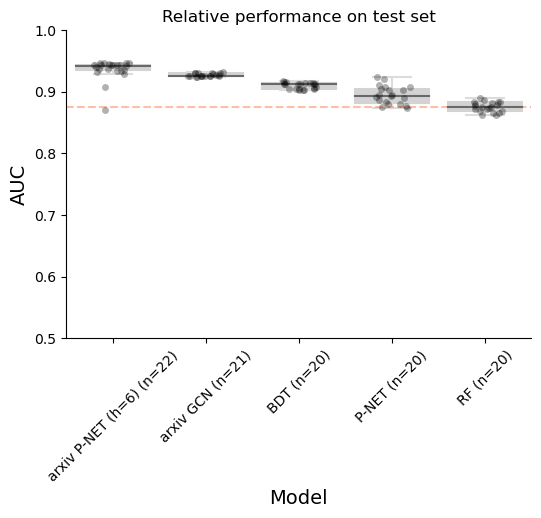

2024-04-12 20:15:16 INFO     saving plot to ../figures/pnet_gcn_arxivPnet_rf_bdt_performance_benchmark_AUC


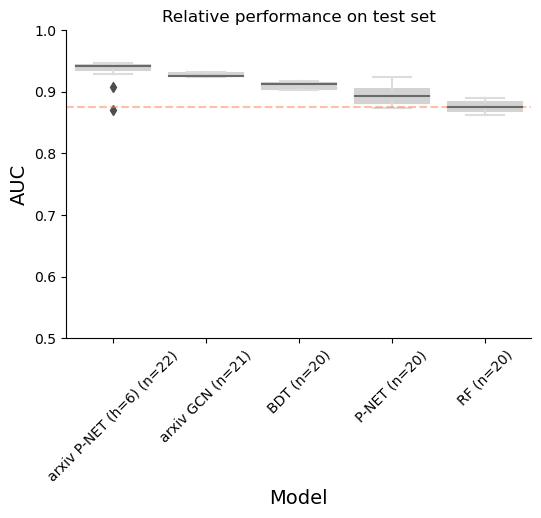

In [120]:
# SAVENAME = 'pnet_rf_bdt_performance_benchmark_AUC_w_points'
SAVENAME = 'pnet_gcn_arxivPnet_rf_bdt_performance_benchmark_AUC_w_points'
# SAVENAME_nopoints = 'pnet_rf_bdt_performance_benchmark_AUC'
SAVENAME_nopoints = 'pnet_gcn_arxivPnet_rf_bdt_performance_benchmark_AUC'

smallest_median_val = auc_df.groupby('Group').median().min().min()

# Set up the boxplot with points using Seaborn
plt.figure(figsize=(6, 4))
sns.boxplot(x='Group', y='Value',
    data=auc_df, color='gray', showfliers=False, boxprops={'facecolor': 'lightgrey', 'color': 'lightgrey'},
                      whiskerprops={'color': 'gainsboro'},
                      capprops={'color': 'gainsboro'},
                      medianprops={'color': 'dimgrey'})
sns.stripplot(x='Group', y='Value', data=auc_df, color='black', jitter=0.2, alpha=0.3)

# Customize plot appearance
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)
plt.axhline(y=smallest_median_val, color='coral', linestyle='--', label=f'y_min = {smallest_median_val}', alpha=0.5)

# Calculate the number of samples in each group
sample_counts = auc_df['Group'].value_counts()
# Create custom x-axis labels with sample counts
x_labels = [f"{group} (n={sample_counts[group]})" for group in sample_counts.index]
plt.xticks(range(len(sample_counts.index)), x_labels, rotation=45)

ax.set_ylabel('AUC', size=14)
ax.set_xlabel('Model', size=14)
ax.set_ylim((0.5, 1))
plt.title("Relative performance on test set")
report_and_eval.savefig(plt, os.path.join(FIGDIR, SAVENAME), png=True, pdf=True)
plt.show()



# Set up the boxplot WITHOUT points using Seaborn
plt.figure(figsize=(6, 4))
sns.boxplot(x='Group', y='Value',
    data=auc_df, color='gray', showfliers=True, boxprops={'facecolor': 'lightgrey', 'color': 'lightgrey'},
                      whiskerprops={'color': 'gainsboro'},
                      capprops={'color': 'gainsboro'},
                      medianprops={'color': 'dimgrey'})

# Customize plot appearance
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)
plt.axhline(y=smallest_median_val, color='coral', linestyle='--', label=f'y_min = {smallest_median_val}', alpha=0.5)

# Calculate the number of samples in each group
sample_counts = auc_df['Group'].value_counts()
# Create custom x-axis labels with sample counts
x_labels = [f"{group} (n={sample_counts[group]})" for group in sample_counts.index]
plt.xticks(range(len(sample_counts.index)), x_labels, rotation=45)


ax.set_ylabel('AUC', size=14)
ax.set_xlabel('Model', size=14)
ax.set_ylim((0.5, 1))
plt.title("Relative performance on test set")
report_and_eval.savefig(plt, os.path.join(FIGDIR, SAVENAME_nopoints), png=True, pdf=True)
plt.show()



# Relative stability of feature importance
- have gene-level for P-NET, RF, and BDT
- also have layer/pathway level information for P-NET

In [145]:
import pickle

# Read gene_imps from a Pickle file (format: len 20 list --> pandas DFs, samples x genes?)
with open(os.path.join(PNET_DIR, 'gene_imps.pkl'), 'rb') as file:
    gene_imps = pickle.load(file)

# Read layerwise_imps from a Pickle file (format: len 20 list --> len 5 list --> pandas DF, samples x features)
with open(os.path.join(PNET_DIR, 'layerwise_imps.pkl'), 'rb') as file:
    layerwise_imps = pickle.load(file)

In [11]:
[i.shape for i in layerwise_imps[0]]

[(102, 734), (102, 845), (102, 449), (102, 159), (102, 29)]

2024-01-31 18:29:49 INFO     Calculating patient-level stability metric
2024-01-31 18:29:49 INFO     Plotting histogram of patient-level stability metric


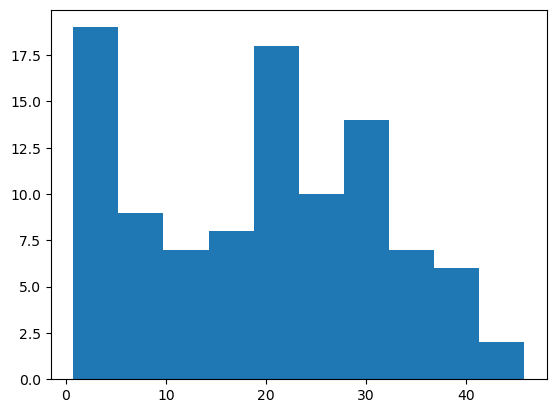

In [12]:
pnet_gene_imps = stability_utils.get_pnet_gene_imps(PNET_DIR)
pnet_patient_stabs = stability_utils.calc_perpatient_stability_metric(pnet_gene_imps)

logging.info("Plotting histogram of patient-level stability metric")
# median stdev of top 50 genes (top 50 relative to each patient). 
# Pretty darn unstable. 
# For example, a gene at rank 50 with a stdev of 50 means that 68% of the time, its rank was between 0 and 100.
plt.hist(pnet_patient_stabs)
plt.show()

In [5]:
MODEL_TYPE = "rf"
EVAL_SET = 'test' # val, validation
SAVEDIR = f'../../pnet/results/somatic_{MODEL_TYPE}_eval_set_{EVAL_SET}' # Gwen's

rf_gene_imps = stability_utils.get_sklearn_feature_imps(SAVEDIR)

In [6]:
# PROBLEM: RF and BDT don't have per-patient feature importances. How did Marc deal with this? He said that he normally grouped by the response variable.
# Maybe I'll just look at the overall model-level stability here. That'll be easiest to compare anyway. :/
print(type(pnet_gene_imps[0]))
print(type(rf_gene_imps[0]))

NameError: name 'pnet_gene_imps' is not defined

In [ ]:
rf_model_stability = stability_utils.calc_model_stability(rf_gene_imps, n_top_genes=50)
rf_model_stability

/var/tmp/ipykernel_21552/3316825710.py:204: DeprecationWarning: The 'warn' function is deprecated, use 'warning' instead
  logging.warn("TODO: check functionality. Is the rankings DF correct?")
2024-01-31 18:29:54 WARNING  TODO: check functionality. Is the rankings DF correct?
2024-01-31 18:29:54 INFO     Convert to rank and sort


2024-01-31 18:29:54 INFO     Compute the average and standard deviation across rows (aka runs)


14.514698846941538

In [ ]:
pd.DataFrame(rf_gene_imps).apply(lambda row: row.abs().rank(ascending=False).sort_values(), axis=1)

,A1CF_somatic_amp,A1CF_somatic_del,A1CF_somatic_mut,AADAC_somatic_amp,AADAC_somatic_del,AADAC_somatic_mut,AAMP_somatic_amp,AAMP_somatic_del,AAMP_somatic_mut,AASDH_somatic_amp,...,ZW10_somatic_mut,ZYG11B_somatic_amp,ZYG11B_somatic_del,ZYG11B_somatic_mut,ZYX_somatic_amp,ZYX_somatic_del,ZYX_somatic_mut,ZZZ3_somatic_amp,ZZZ3_somatic_del,ZZZ3_somatic_mut
0,443.0,10702.0,1447.0,524.0,10702.0,10702.0,10702.0,10702.0,10702.0,10702.0,...,3609.0,10702.0,10702.0,10702.0,6162.0,10702.0,10702.0,10702.0,10702.0,3660.0
1,4418.5,10676.5,1286.0,3914.0,10676.5,10676.5,10676.5,10676.5,4225.0,5723.5,...,10676.5,10676.5,10676.5,10676.5,1409.0,10676.5,10676.5,10676.5,3218.0,10676.5
2,158.0,10702.0,735.0,661.0,10702.0,10702.0,4278.5,10702.0,10702.0,10702.0,...,1279.0,10702.0,10702.0,10702.0,5727.0,10702.0,10702.0,6034.0,10702.0,4756.0
3,10673.5,3760.0,2148.0,1684.0,10673.5,10673.5,10673.5,10673.5,10673.5,10673.5,...,3515.0,10673.5,10673.5,10673.5,2999.0,4642.0,10673.5,10673.5,4496.0,10673.5
4,2328.0,10698.5,2182.0,1157.0,10698.5,10698.5,10698.5,10698.5,5798.0,10698.5,...,3606.0,10698.5,10698.5,10698.5,6007.0,10698.5,10698.5,10698.5,4331.0,10698.5
5,363.0,10718.5,4740.0,2612.0,10718.5,10718.5,10718.5,10718.5,10718.5,10718.5,...,1760.0,10718.5,4938.0,10718.5,4483.5,10718.5,10718.5,6229.0,3286.0,10718.5
6,325.0,10662.0,2224.0,531.0,10662.0,10662.0,1430.0,2370.0,10662.0,3647.0,...,10662.0,10662.0,10662.0,10662.0,4645.0,10662.0,10662.0,10662.0,4373.0,10662.0
7,911.0,10662.5,839.0,2026.0,677.0,10662.5,1218.0,3574.0,10662.5,10662.5,...,3558.0,10662.5,1717.0,10662.5,6410.0,4905.0,10662.5,10662.5,10662.5,10662.5
8,10667.0,10667.0,1032.0,3449.0,5185.0,10667.0,10667.0,10667.0,10667.0,5619.0,...,2475.0,10667.0,5462.5,10667.0,6172.0,10667.0,1813.0,5437.0,5650.0,10667.0
9,1544.0,10668.0,5108.0,5342.0,2751.0,10668.0,10668.0,10668.0,10668.0,10668.0,...,3848.0,10668.0,10668.0,10668.0,1861.0,10668.0,1704.0,3287.0,2128.0,5742.0


In [18]:
# TODO: create sorted DF across all runs
for i in range(len(rf_gene_imps)):
    print(f"Run {i}")
    print(rf_gene_imps[i].rank(ascending=False).sort_values()[:10])
    print("\n")

Run 0
AR_somatic_amp           1.0
AR_somatic_mut           2.0
PTEN_somatic_del         3.0
TP53_somatic_mut         4.0
TSPYL5_somatic_amp       5.0
PDGFA_somatic_amp        6.0
ADAMTS12_somatic_mut     7.0
PDE4DIP_somatic_mut      8.0
GABRA6_somatic_mut       9.0
SCAP_somatic_mut        10.0
dtype: float64


Run 1
AR_somatic_amp        1.0
AR_somatic_mut        2.0
TP53_somatic_mut      3.0
PTEN_somatic_del      4.0
PREX2_somatic_mut     5.0
PDGFA_somatic_amp     6.0
UNC5B_somatic_amp     7.0
SCAP_somatic_mut      8.0
LRP2_somatic_mut      9.0
PXDNL_somatic_mut    10.0
dtype: float64


Run 2
AR_somatic_amp         1.0
AR_somatic_mut         2.0
TP53_somatic_mut       3.0
PTEN_somatic_del       4.0
PDGFA_somatic_amp      5.0
FCHSD1_somatic_mut     6.0
TSPYL5_somatic_amp     7.0
PREX2_somatic_mut      8.0
ZMIZ1_somatic_amp      9.0
NOM1_somatic_del      10.0
dtype: float64


Run 3
AR_somatic_amp        1.0
AR_somatic_mut        2.0
TP53_somatic_mut      3.0
PTEN_somatic_del      4.0
P

In [140]:
MODEL_TYPE = "bdt"
EVAL_SET = 'test' # val
SAVEDIR = f'../../pnet/results/somatic_{MODEL_TYPE}_eval_set_{EVAL_SET}' # Gwen's

bdt_gene_imps = stability_utils.get_sklearn_feature_imps(SAVEDIR)
bdt_model_stability = stability_utils.calc_model_stability(bdt_gene_imps, n_top_genes=50)
bdt_model_stability

2024-05-29 22:01:53 WARNING  TODO: check functionality. Is the rankings DF correct?
2024-05-29 22:01:53 INFO     Convert to rank and sort
2024-05-29 22:01:53 INFO     Compute the average and standard deviation across rows (aka runs)


2.392972166464475

In [19]:
## Here we create a runs x feature rank DF (values = feature name). This is useful for comparing across runs. The input was a list of series, where each series is the gene imp list from a given run.
# Create a DataFrame to store the ranks
rank_df = pd.DataFrame()
tmp_ranks = []
series_list = bdt_gene_imps
# series_list = rf_gene_imps
# Iterate through each series, calculate ranks, and add to the DataFrame
for i in range(len(series_list)):
    series = series_list[i]
    # Calculate ranks and convert them to integers
    ranks = series.abs().rank(ascending=False, method='dense').astype(int).sort_values()
    tmp_ranks.append(ranks.index.tolist())
    # Add ranks to the DataFrame
    # rank_df[series.name] = ranks

# Display the resulting DataFrame
N = 10
rank_df = pd.DataFrame(tmp_ranks)
display(rank_df.loc[:,:N])

print(rank_df.loc[:,:N].stack().value_counts())
top_unique_features = rank_df.loc[:,:N].stack().unique()
print([i.split("_")[0] for i in top_unique_features])
print(len(top_unique_features))


# Display a gene x rank DF (value = # times that gene had that rank across the N=20 runs)
top_gene_by_rank_consistency_df = rank_df.loc[:,:N].apply(lambda col: col.value_counts()).fillna('').reindex(top_unique_features)
display(top_gene_by_rank_consistency_df)

,0,1,2,3,4,5,6,7,8,9,10
0,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,SDAD1_somatic_mut
1,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,LRP2_somatic_mut
2,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,PPIF_somatic_amp
3,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,SDAD1_somatic_mut
4,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,SDAD1_somatic_mut
5,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,LRP2_somatic_mut
6,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,ARL14_somatic_mut,STEAP4_somatic_mut,SDAD1_somatic_mut
7,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,PPIF_somatic_amp
8,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,ARL14_somatic_mut,STEAP4_somatic_mut,SDAD1_somatic_mut
9,AR_somatic_amp,AR_somatic_mut,TP53_somatic_mut,PTEN_somatic_del,PDGFA_somatic_amp,KLHDC8A_somatic_amp,NOM1_somatic_del,FBXO4_somatic_amp,STEAP4_somatic_mut,ARL14_somatic_mut,SDAD1_somatic_mut


AR_somatic_amp         20
AR_somatic_mut         20
TP53_somatic_mut       20
PTEN_somatic_del       20
PDGFA_somatic_amp      20
KLHDC8A_somatic_amp    20
NOM1_somatic_del       20
FBXO4_somatic_amp      20
STEAP4_somatic_mut     20
ARL14_somatic_mut      20
SDAD1_somatic_mut       7
LRP2_somatic_mut        7
PPIF_somatic_amp        6
dtype: int64
['AR', 'AR', 'TP53', 'PTEN', 'PDGFA', 'KLHDC8A', 'NOM1', 'FBXO4', 'STEAP4', 'ARL14', 'SDAD1', 'LRP2', 'PPIF']
13


,0,1,2,3,4,5,6,7,8,9,10
AR_somatic_amp,20.0,,,,,,,,,,
AR_somatic_mut,,20.0,,,,,,,,,
TP53_somatic_mut,,,20.0,,,,,,,,
PTEN_somatic_del,,,,20.0,,,,,,,
PDGFA_somatic_amp,,,,,20.0,,,,,,
KLHDC8A_somatic_amp,,,,,,20.0,,,,,
NOM1_somatic_del,,,,,,,20.0,,,,
FBXO4_somatic_amp,,,,,,,,20.0,,,
STEAP4_somatic_mut,,,,,,,,,18.0,2.0,
ARL14_somatic_mut,,,,,,,,,2.0,18.0,


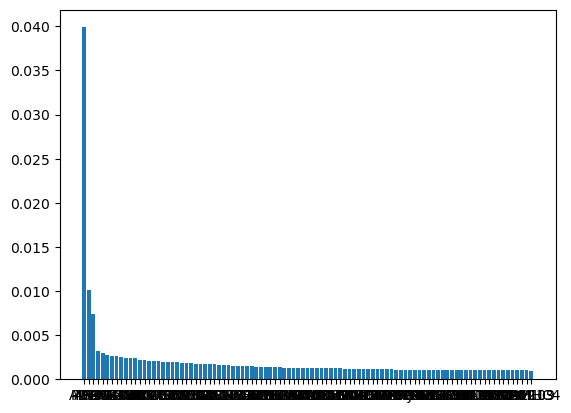

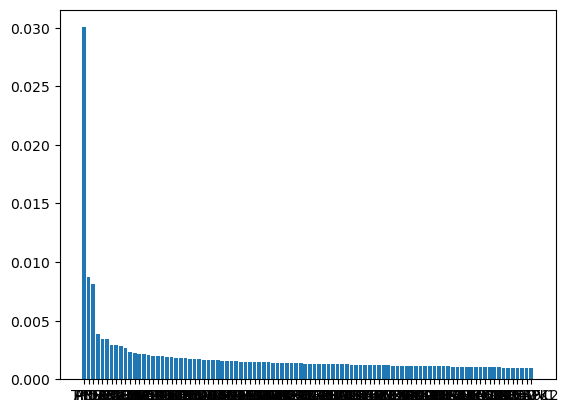

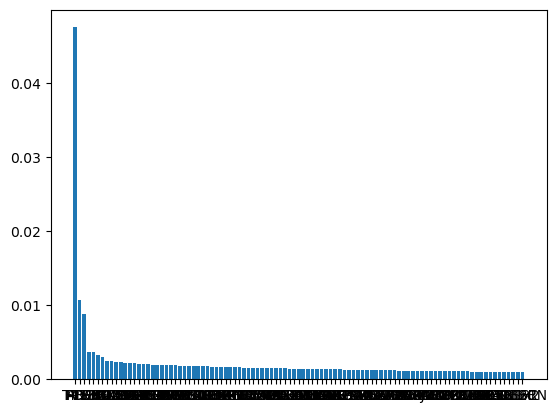

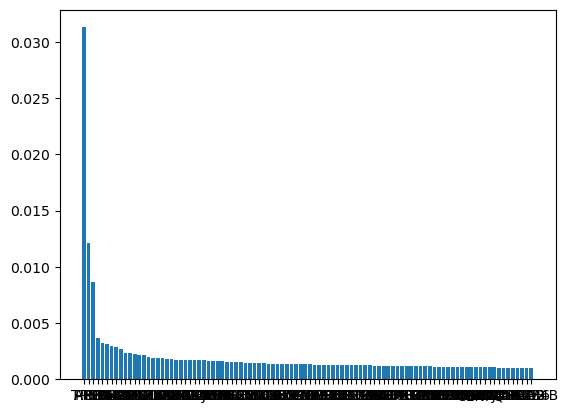

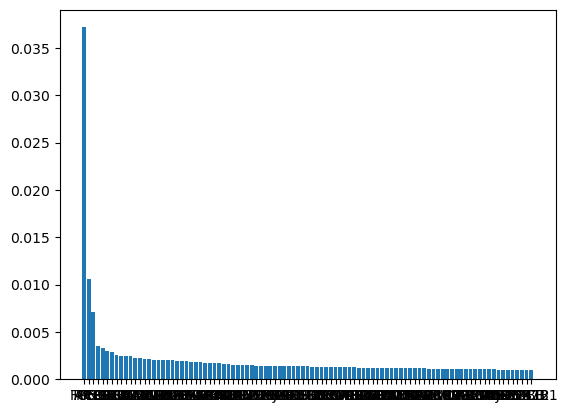

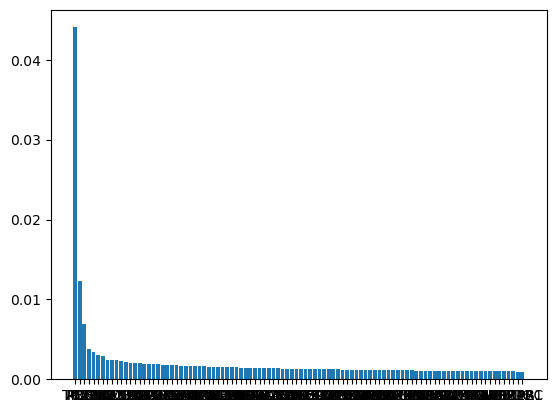

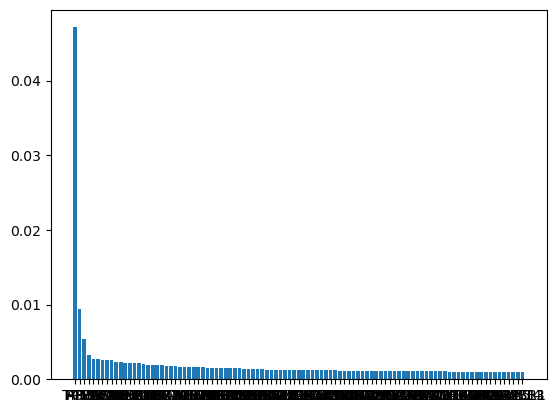

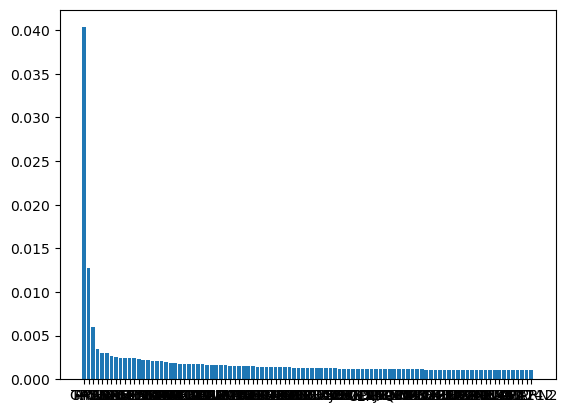

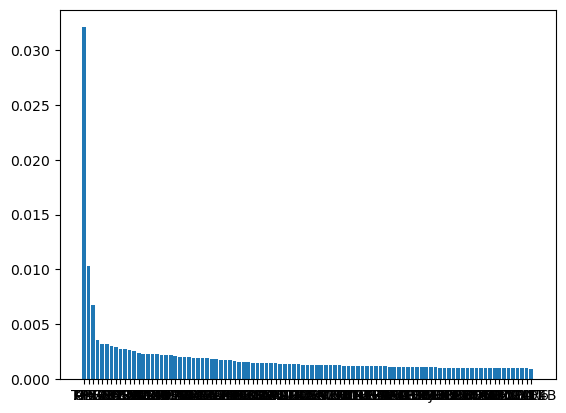

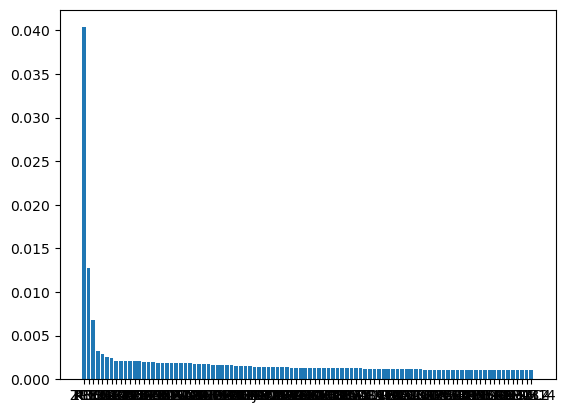

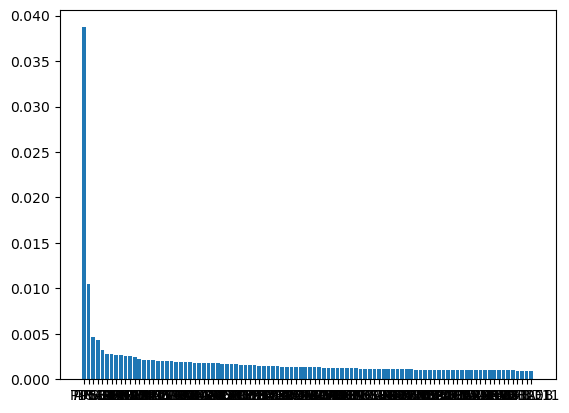

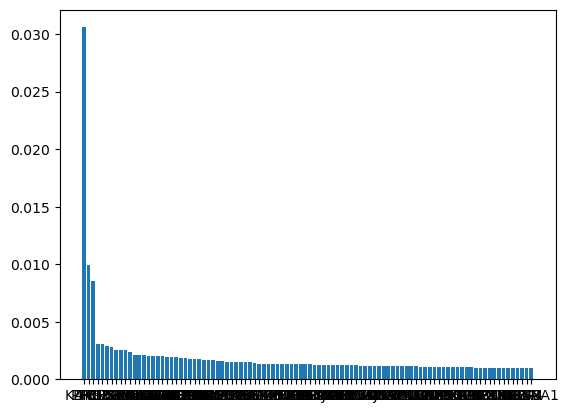

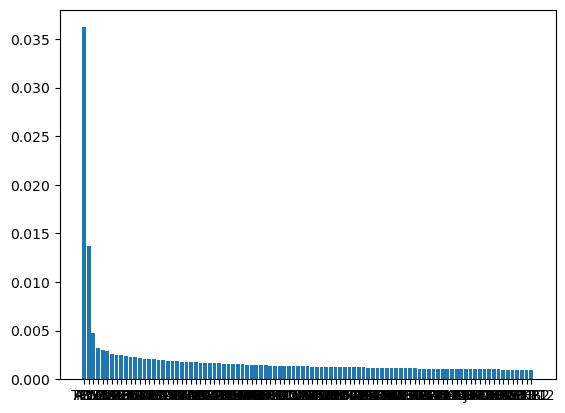

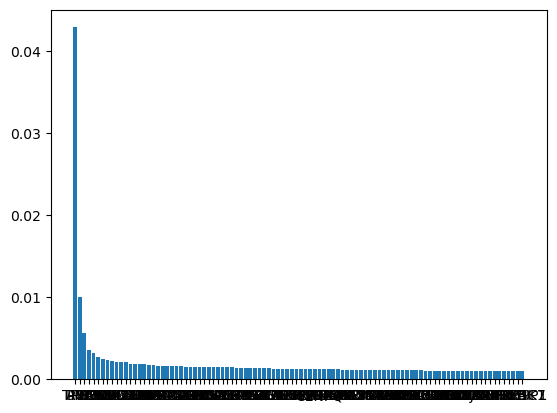

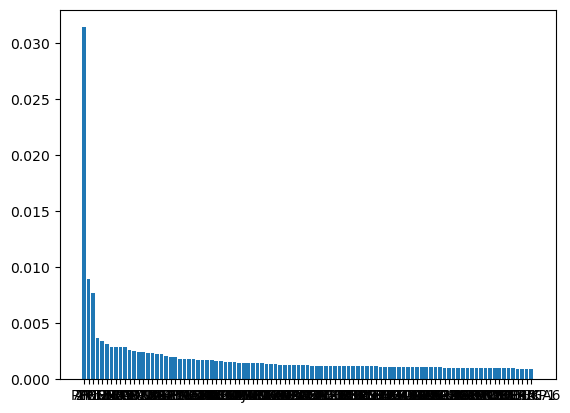

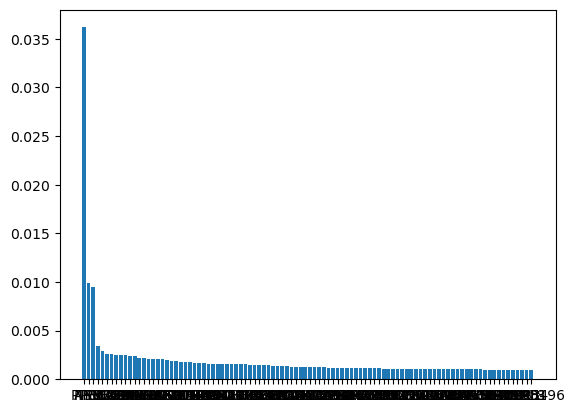

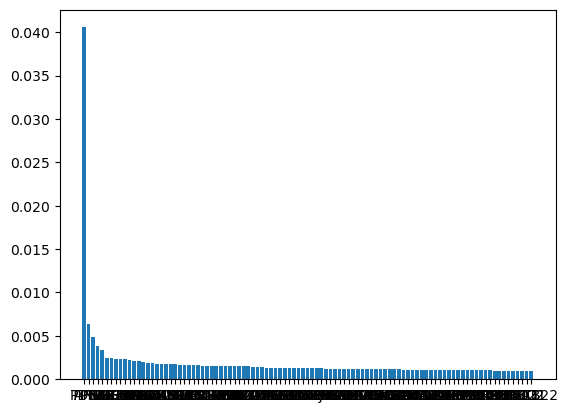

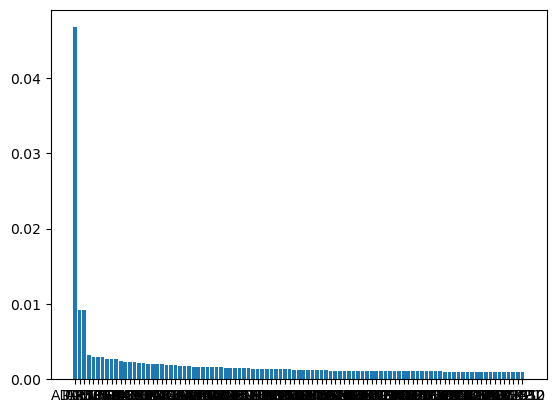

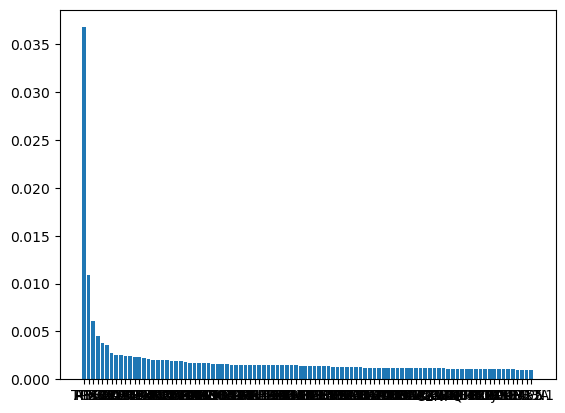

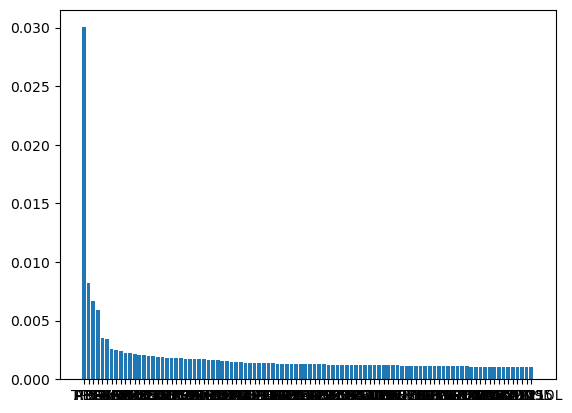

In [60]:
for run in range(len(rf_gene_imps)):
    top_rank_run1 = rf_gene_imps[run].rank(ascending=False).sort_values().index[:100]
    plt.bar([i.split('_')[0] for i in top_rank_run1], rf_gene_imps[run].loc[top_rank_run1])
    plt.show()

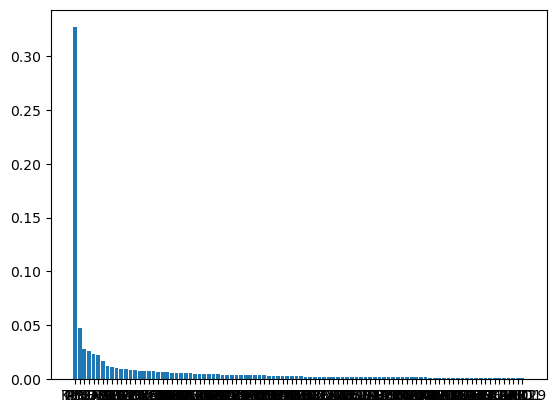

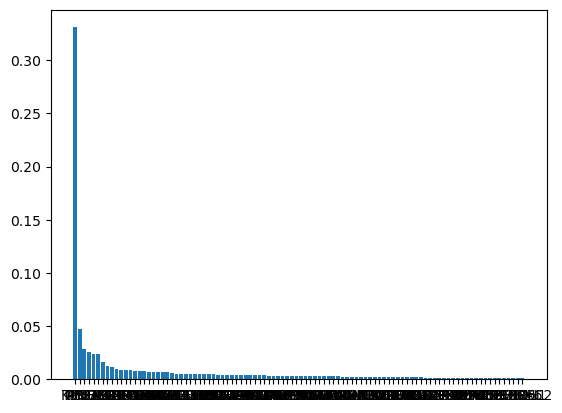

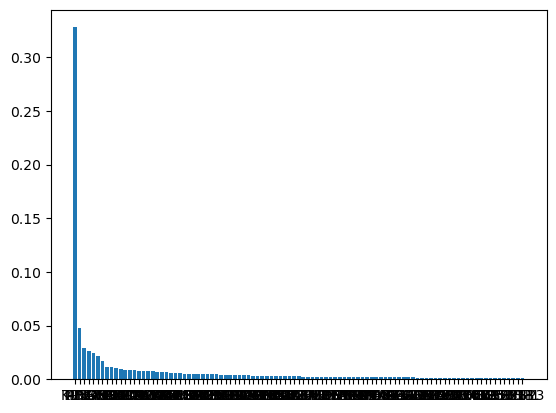

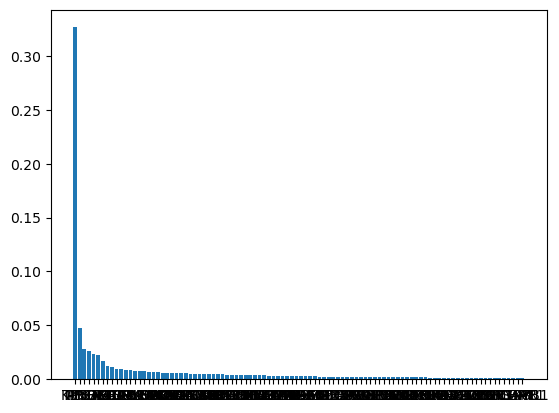

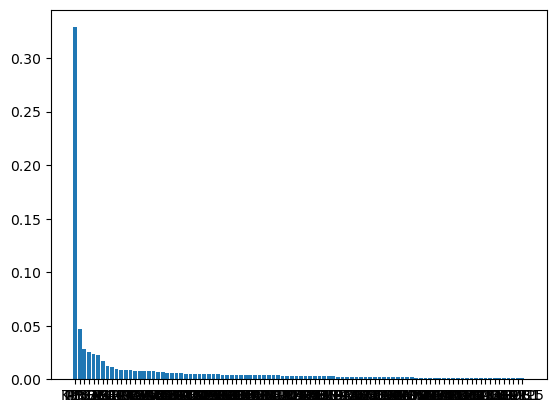

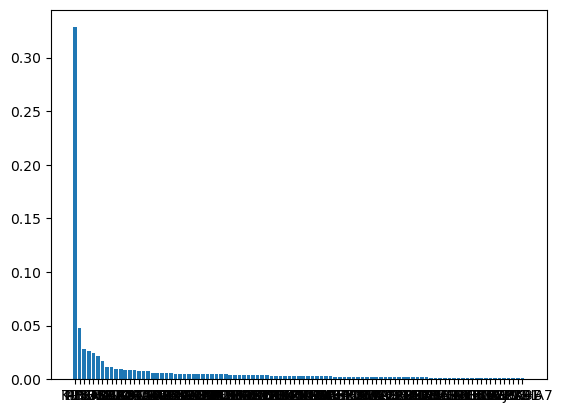

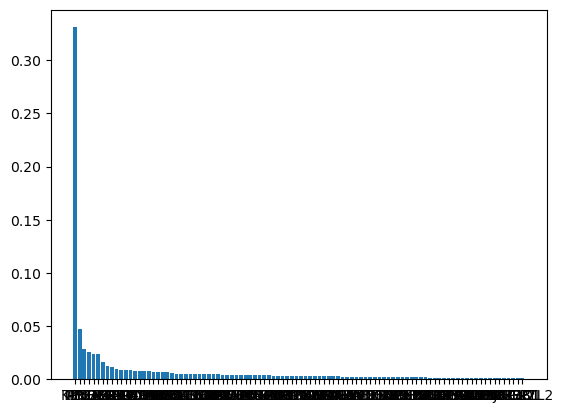

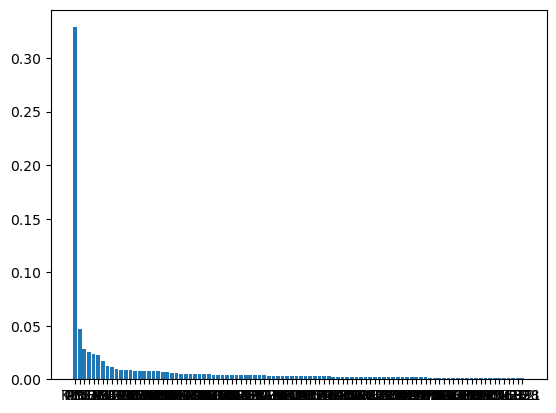

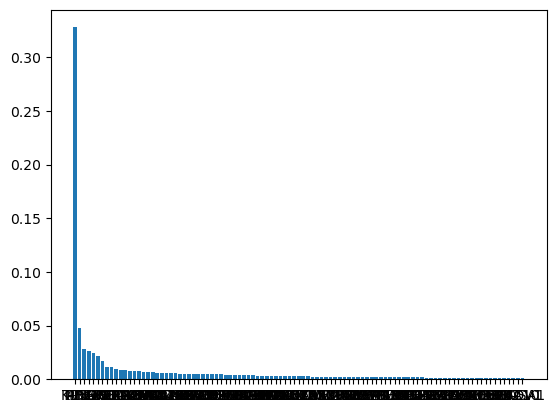

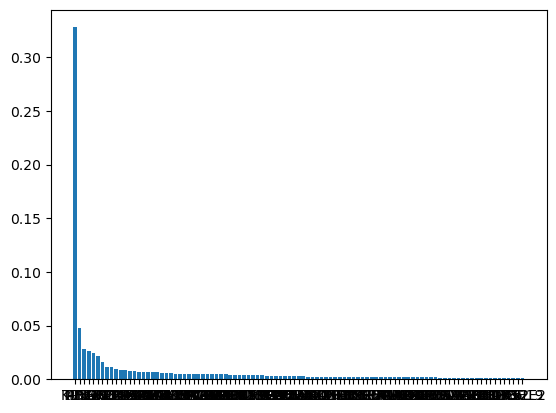

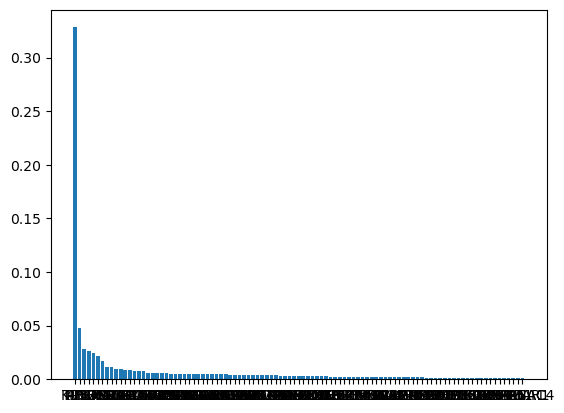

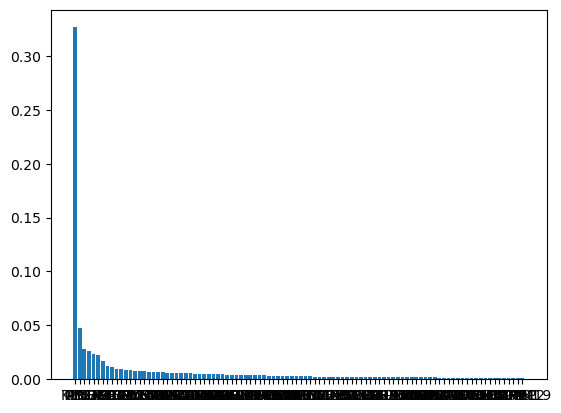

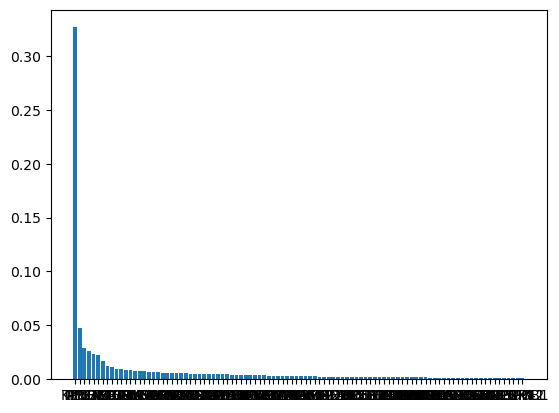

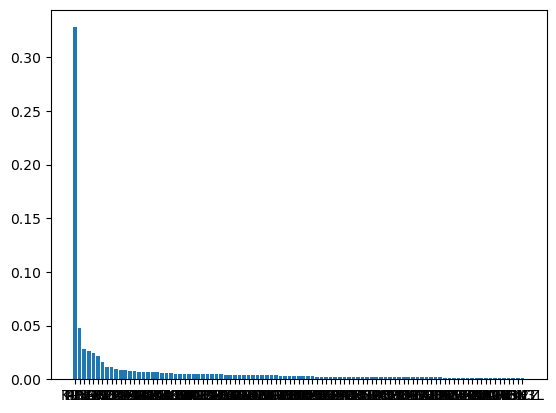

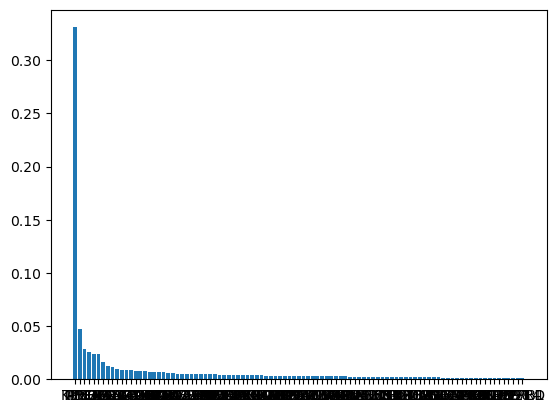

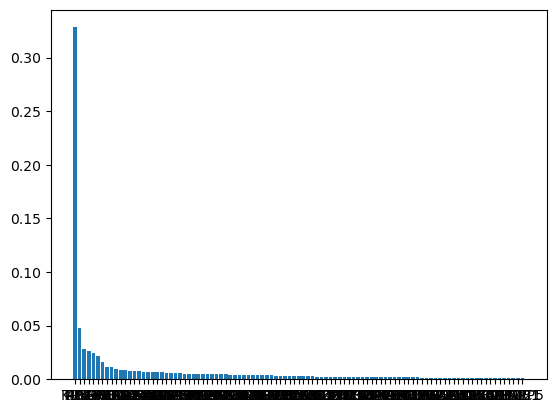

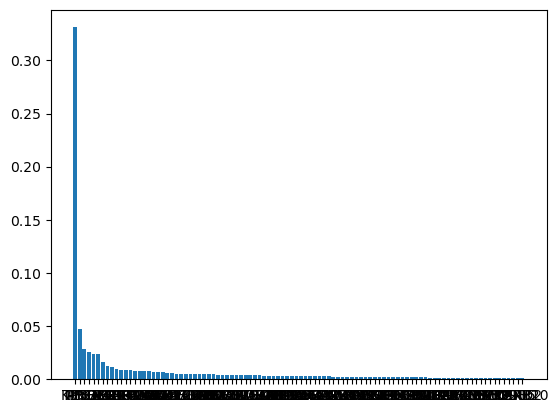

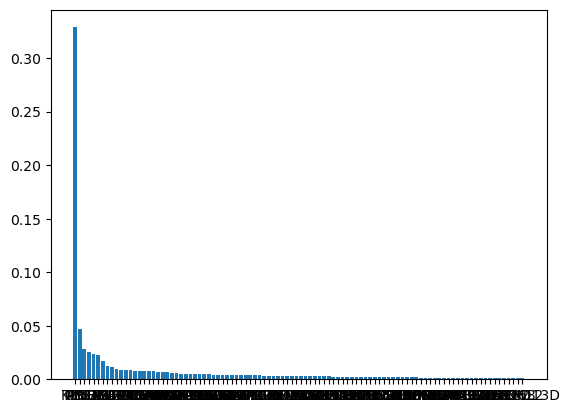

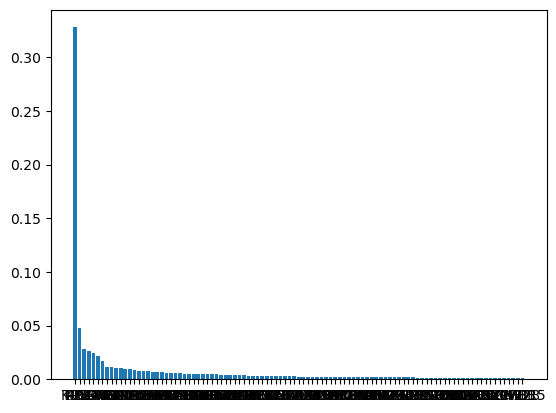

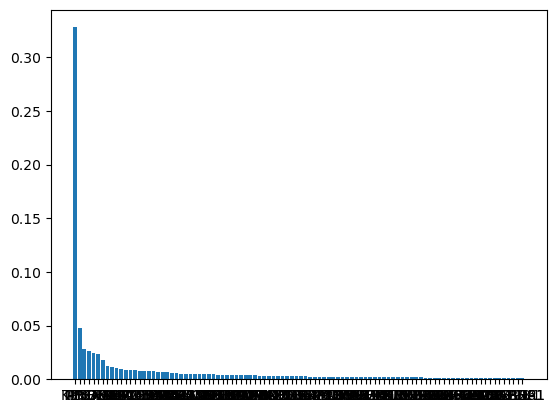

In [59]:
for run in range(len(bdt_gene_imps)):
    top_rank_run1 = bdt_gene_imps[run].rank(ascending=False).sort_values().index[:100]
    plt.bar([i.split('_')[0] for i in top_rank_run1], bdt_gene_imps[run].loc[top_rank_run1])
    plt.show()

In [97]:
logging.info("Exploring the ranks particular features of interest")
tmp = []
for run in range(len(bdt_gene_imps)):
    tmp.append(bdt_gene_imps[run].rank(ascending=False).sort_values()[
        ['MDM4_somatic_amp', 'MDM4_somatic_del', 'MDM4_somatic_mut']
        # ['FGFR1_somatic_amp', 'FGFR1_somatic_del', 'FGFR1_somatic_mut']
        ].tolist())
tmp

[[7457.5, 7457.5, 7457.5],
 [7451.5, 7451.5, 7451.5],
 [7450.5, 7450.5, 7450.5],
 [7457.0, 7457.0, 7457.0],
 [7453.0, 7453.0, 7453.0],
 [7456.0, 7456.0, 7456.0],
 [7450.5, 7450.5, 7450.5],
 [7452.0, 7452.0, 7452.0],
 [7452.5, 7452.5, 7452.5],
 [7452.0, 7452.0, 7452.0],
 [7456.0, 7456.0, 7456.0],
 [7458.0, 7458.0, 7458.0],
 [7458.5, 7458.5, 7458.5],
 [7452.0, 7452.0, 7452.0],
 [7450.5, 7450.5, 7450.5],
 [7452.5, 7452.5, 7452.5],
 [7451.0, 7451.0, 7451.0],
 [7455.5, 7455.5, 7455.5],
 [7452.0, 7452.0, 7452.0],
 [7454.5, 7454.5, 7454.5]]

## Exploring magnitude of feature importances
- How change from model to model?
- What does the distribution look like across top genes? All genes? Flat, or large drop-off?

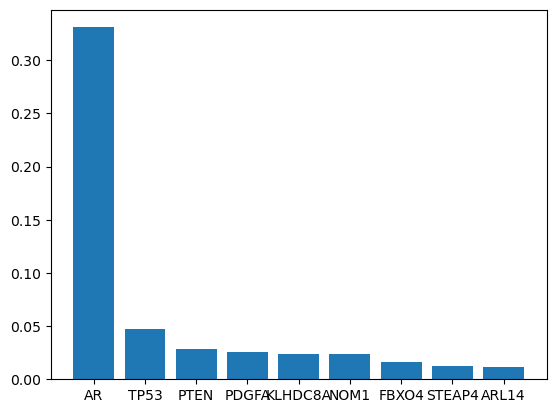

In [62]:
run=1
top_rank_run1 = bdt_gene_imps[run].rank(ascending=False).sort_values().index[:10]
plt.bar([i.split('_')[0] for i in top_rank_run1], bdt_gene_imps[run].loc[top_rank_run1])
plt.show()

In [21]:
# TODO: create sorted DF across all runs
for i in range(len(bdt_gene_imps)):
    print(f"Run {i}")
    print(bdt_gene_imps[i].rank(ascending=False).sort_values()[:10])
    print("\n")

Run 0
AR_somatic_amp          1.0
AR_somatic_mut          2.0
TP53_somatic_mut        3.0
PTEN_somatic_del        4.0
PDGFA_somatic_amp       5.0
KLHDC8A_somatic_amp     6.0
NOM1_somatic_del        7.0
FBXO4_somatic_amp       8.0
STEAP4_somatic_mut      9.0
ARL14_somatic_mut      10.0
dtype: float64


Run 1
AR_somatic_amp          1.0
AR_somatic_mut          2.0
TP53_somatic_mut        3.0
PTEN_somatic_del        4.0
PDGFA_somatic_amp       5.0
KLHDC8A_somatic_amp     6.0
NOM1_somatic_del        7.0
FBXO4_somatic_amp       8.0
STEAP4_somatic_mut      9.0
ARL14_somatic_mut      10.0
dtype: float64


Run 2
AR_somatic_amp          1.0
AR_somatic_mut          2.0
TP53_somatic_mut        3.0
PTEN_somatic_del        4.0
PDGFA_somatic_amp       5.0
KLHDC8A_somatic_amp     6.0
NOM1_somatic_del        7.0
FBXO4_somatic_amp       8.0
ARL14_somatic_mut       9.0
STEAP4_somatic_mut     10.0
dtype: float64


Run 3
AR_somatic_amp          1.0
AR_somatic_mut          2.0
TP53_somatic_mut        3.0
P

In [ ]:
tmp_ranking = pd.DataFrame(rf_gene_imps).apply(lambda row: row.abs().rank(ascending=False), axis=1)
tmp_ranking.loc[:,['MDM4_somatic_mut', 'MDM4_somatic_amp', 'MDM4_somatic_del']]

,MDM4_somatic_mut,MDM4_somatic_amp,MDM4_somatic_del
0,5983.0,10702.0,10702.0
1,5989.0,2258.0,10676.5
2,4866.0,10702.0,10702.0
3,6308.0,1248.0,10673.5
4,6225.0,1075.0,10698.5
5,6376.0,1967.0,10718.5
6,10662.0,10662.0,10662.0
7,6561.0,368.0,10662.5
8,6398.0,202.0,10667.0
9,6565.0,556.0,10668.0


In [100]:
logging.info("Checking that both methods return the same result.")
pnet_rankings = stability_utils.make_perpatient_rankings_dfs(pnet_gene_imps)
print(pnet_rankings[0].loc[:,'MDM4'])
pnet_patient_0_rank = stability_utils.make_pnet_gene_ranking_df(pnet_gene_imps, 0)
pnet_patient_0_rank.loc[:,'MDM4']

# calc_stability_metric_on_runs_by_generank_df(rankings_df, n_top_genes)

2024-01-22 20:30:51 INFO     Checking that both methods return the same result.


0     10.0
1     46.0
2     23.0
3     13.0
4     26.0
5      8.0
6     47.0
7     28.0
8     10.0
9     26.0
10    10.0
11     5.0
12    13.0
13    36.0
14    10.0
15    63.0
16    46.0
17    55.0
18    66.0
19    20.0
Name: MDM4, dtype: float64


MO_1124    10.0
MO_1124    46.0
MO_1124    23.0
MO_1124    13.0
MO_1124    26.0
MO_1124     8.0
MO_1124    47.0
MO_1124    28.0
MO_1124    10.0
MO_1124    26.0
MO_1124    10.0
MO_1124     5.0
MO_1124    13.0
MO_1124    36.0
MO_1124    10.0
MO_1124    63.0
MO_1124    46.0
MO_1124    55.0
MO_1124    66.0
MO_1124    20.0
Name: MDM4, dtype: float64